<a href="https://colab.research.google.com/github/GUIVICFISHER/RiskNeutralKernel2026/blob/main/risk_analysis_stock_erase_01%20REVIEW%20CALAMY%20!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Tickers for Dot-Com era analysis
dot_com_era_tickers = {
    'Cisco': 'CSCO',
    'Intel': 'INTC',
    'Microsoft': 'MSFT',
    'Amazon': 'AMZN'
}

# Define the specific period for Dot-Com analysis (e.g., 1997 to 2003)
START_DATE = "1997-01-01"
END_DATE = "2003-12-31"

plt.figure(figsize=(18, 15))
plt.suptitle('Dot-Com Era: Stock Price vs. Debt-to-Equity Ratio (1997-2003)', y=1.02, fontsize=16)

plot_idx = 1
for company_name, ticker_symbol in dot_com_era_tickers.items():
    print(f"\nProcessing {company_name} ({ticker_symbol})...")
    try:
        # 1. Fetch historical daily prices
        price_data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")
        if price_data.empty:
            print(f"No price data found for {company_name}. Skipping.")
            continue

        price_series = pd.Series(dtype=float) # Initialize an empty Series

        if 'Adj Close' in price_data.columns and not price_data['Adj Close'].empty:
            price_series = price_data['Adj Close'].squeeze()
        elif 'Close' in price_data.columns and not price_data['Close'].empty:
            price_series = price_data['Close'].squeeze()

        if price_series.empty: # Check if a valid series was extracted
            print(f"No valid price series (Adj Close or Close) found for {company_name}. Skipping.")
            continue

        # 2. Fetch quarterly balance sheets to calculate Debt-to-Equity
        ticker = yf.Ticker(ticker_symbol)
        balance_sheet_quarterly = ticker.quarterly_balance_sheet

        # Check if balance sheet data is available and has required fields
        if balance_sheet_quarterly.empty:
            print(f"No quarterly balance sheet data found for {company_name}. Skipping.")
            continue

        # Transpose to have dates as index
        balance_sheet_quarterly = balance_sheet_quarterly.T

        # Find relevant debt and equity keys (checking for common variations)
        total_debt_keys = ['Total Debt', 'Long Term Debt And Capital Lease Obligation', 'Long Term Debt', 'Current Debt And Capital Lease Obligation']
        equity_keys = ['Stockholders Equity', 'Total Equity Gross Minority Interest', 'Share Holder Equity']

        total_debt = pd.Series(dtype=float)
        for key in total_debt_keys:
            if key in balance_sheet_quarterly.columns:
                total_debt = balance_sheet_quarterly[key]
                break
        if total_debt.empty:
             # Attempt to sum common debt components if 'Total Debt' not found directly
            current_debt = balance_sheet_quarterly.get('Current Debt And Capital Lease Obligation', 0)
            long_term_debt = balance_sheet_quarterly.get('Long Term Debt And Capital Lease Obligation', 0)
            if isinstance(current_debt, pd.Series) and isinstance(long_term_debt, pd.Series):
                total_debt = current_debt.fillna(0) + long_term_debt.fillna(0)
            elif isinstance(current_debt, pd.Series): total_debt = current_debt
            elif isinstance(long_term_debt, pd.Series): total_debt = long_term_debt

        shareholder_equity = pd.Series(dtype=float)
        for key in equity_keys:
            if key in balance_sheet_quarterly.columns:
                shareholder_equity = balance_sheet_quarterly[key]
                break

        # Filter D/E data to the specified period and drop NaNs
        period_date_range = pd.to_datetime(pd.date_range(START_DATE, END_DATE))

        total_debt_filtered = total_debt.loc[total_debt.index.intersection(period_date_range)].dropna()
        shareholder_equity_filtered = shareholder_equity.loc[shareholder_equity.index.intersection(period_date_range)].dropna()

        if total_debt_filtered.empty or shareholder_equity_filtered.empty:
            print(f"Could not find sufficient non-NaN debt or equity data for {company_name} within the specified period. Skipping.")
            continue

        # Align indices of total_debt and shareholder_equity for division
        common_index = total_debt_filtered.index.intersection(shareholder_equity_filtered.index)
        if common_index.empty:
            print(f"No common dates with non-NaN debt and equity data for {company_name}. Skipping.")
            continue

        total_debt_aligned = total_debt_filtered.loc[common_index]
        shareholder_equity_aligned = shareholder_equity_filtered.loc[common_index]

        # Handle zero shareholder equity to avoid division by zero
        # Replace zero equity with NaN so it gets dropped or handled gracefully
        shareholder_equity_aligned_no_zero = shareholder_equity_aligned.replace(0, np.nan)

        if shareholder_equity_aligned_no_zero.dropna().empty:
            print(f"Shareholder Equity is zero or NaN for all available dates for {company_name}. Skipping.")
            continue

        # Calculate Debt-to-Equity ratio
        debt_to_equity = total_debt_aligned / shareholder_equity_aligned_no_zero
        debt_to_equity = debt_to_equity.replace([np.inf, -np.inf], np.nan).dropna() # drop any remaining inf/nan from division

        if debt_to_equity.empty:
            print(f"Calculated Debt-to-Equity is empty after cleaning for {company_name}. Skipping.")
            continue

        # 3. Align D/E (quarterly) with daily prices
        # Create a daily date range within the analysis period
        full_date_range = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
        aligned_de = pd.Series(index=full_date_range, dtype=float)

        # Forward-fill quarterly D/E values to daily dates
        for q_date in sorted(debt_to_equity.index):
            # Find all daily dates from this quarter-end until the next quarter-end or end of period
            if q_date <= pd.to_datetime(END_DATE):
                start_fill_date = q_date
                next_q_dates = [d for d in debt_to_equity.index if d > q_date]
                end_fill_date = next_q_dates[0] if next_q_dates else pd.to_datetime(END_DATE)

                # Ensure end_fill_date is within the overall range and after start_fill_date
                end_fill_date = min(end_fill_date, pd.to_datetime(END_DATE))

                daily_dates_to_fill = pd.date_range(start=start_fill_date, end=end_fill_date, freq='D')
                # Make sure the dates are valid for the index
                daily_dates_to_fill = daily_dates_to_fill[daily_dates_to_fill.isin(aligned_de.index)]

                if not daily_dates_to_fill.empty:
                    aligned_de.loc[daily_dates_to_fill] = debt_to_equity.loc[q_date]

        # Fill any remaining NaNs at the beginning with the first available value
        aligned_de = aligned_de.ffill().loc[price_series.index] # Align to price_series index after ffill

        # 4. Plotting
        ax1 = plt.subplot(2, 2, plot_idx) # Price on left y-axis
        color = 'tab:blue'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Stock Price', color=color)
        ax1.plot(price_series.index, price_series, color=color, label='Stock Price')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.set_title(f'{company_name} ({ticker_symbol})')
        ax1.grid(True)
        ax1.tick_params(axis='x', rotation=45)

        ax2 = ax1.twinx() # Debt-to-Equity on right y-axis
        color = 'tab:red'
        ax2.set_ylabel('Debt-to-Equity Ratio', color=color)
        ax2.plot(aligned_de.index, aligned_de, color=color, linestyle='--', label='Debt-to-Equity Ratio')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_ylim(bottom=0) # Ensure D/E starts from 0 for better visualization

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        plot_idx += 1

    except Exception as e:
        print(f"Error processing {company_name} ({ticker_symbol}): {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

/tmp/ipykernel_25506/197087235.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25506/197087235.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25506/197087235.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")
[*********************100%***********************]  1 of 1 completed


Processing Cisco (CSCO)...
Could not find sufficient non-NaN debt or equity data for Cisco within the specified period. Skipping.

Processing Intel (INTC)...
Could not find sufficient non-NaN debt or equity data for Intel within the specified period. Skipping.

Processing Microsoft (MSFT)...



/tmp/ipykernel_25506/197087235.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")
[*********************100%***********************]  1 of 1 completed


Could not find sufficient non-NaN debt or equity data for Microsoft within the specified period. Skipping.

Processing Amazon (AMZN)...
Could not find sufficient non-NaN debt or equity data for Amazon within the specified period. Skipping.


<Figure size 1800x1500 with 0 Axes>

### Comparison of Bubble Indicators for Current Era Stocks

To facilitate a direct comparison of the 'Bubble Indicator' across all current era stocks, we will plot their indicators on a single graph. This allows us to observe which stocks exhibit similar patterns, higher volatility, or more pronounced 'bubble' characteristics relative to each other over the same time period.

### 1. Financial Modeling Prep (FMP)

In [ ]:
# Removed: Installation for 'financialdatareader' failed and is not required for FMP data fetching via 'requests'.
# !pip install financialdatareader

In [ ]:
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
try:
    FMP_API_KEY = userdata.get('FMP_API_KEY')
except Exception as e:
    print(f"Error: {e}")
    print("Please ensure your FMP API key is valid and correctly entered in Colab secrets as 'FMP_API_KEY'.")
    FMP_API_KEY = None # Set to None to prevent further execution if key is missing

# Note: The original code intended to use requests for robustness, which is still the case.
import requests

ticker_symbol = 'AAPL'

if FMP_API_KEY:
    print(f"\nAttempting to fetch Income Statement for {ticker_symbol} using FMP...")

    try:
        # FMP API endpoint for quarterly income statement
        url = f"https://financialmodelingprep.com/api/v3/income-statement/{ticker_symbol}?period=quarter&apikey={FMP_API_KEY}"
        response = requests.get(url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        income_statement_data = response.json()

        if income_statement_data:
            income_statement_df = pd.DataFrame(income_statement_data)
            # Convert 'date' column to datetime and set as index for better analysis
            income_statement_df['date'] = pd.to_datetime(income_statement_df['date'])
            income_statement_df = income_statement_df.set_index('date').sort_index()
            print(f"\nIncome Statement data from FMP for {ticker_symbol} (first 5 rows):")
            display(income_statement_df.head())
        else:
            print(f"No Income Statement data found for {ticker_symbol} via FMP. Check API key and ticker.")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching Income Statement for {ticker_symbol} with FMP: {e}")
        print("Please ensure your FMP API key is valid and correctly entered in Colab secrets as 'FMP_API_KEY'.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
else:
    print("Skipping FMP data fetch because the API key was not found or an error occurred.")

Error: Secret FMP_API_KEY does not exist.
Please ensure your FMP API key is valid and correctly entered in Colab secrets as 'FMP_API_KEY'.
Skipping FMP data fetch because the API key was not found or an error occurred.


### 2. Quandl (now Nasdaq Data Link)

**Note:** While Quandl (now Nasdaq Data Link) offers some free datasets, its primary value often comes from premium, curated datasets. The free datasets usually require some exploration on their website to find what's available without a paid subscription.

To use Quandl:

1.  **Get an API Key:** Sign up on the [Nasdaq Data Link website](https://data.nasdaq.com/sign-up) to get your API key.
2.  **Store it securely:** Add your API key to Colab's Secrets Manager with the name `NASDAQ_DATA_LINK_API_KEY`.
3.  **Install the library:** I'll provide code to install the `Quandl` Python library.
4.  **Fetch data:** We'll attempt to fetch a sample free dataset, like a key economic indicator (e.g., from the FRED database, which is often available through Quandl).


Certainly! Here's a comprehensive explanation of the mathematical expressions and conceptual framework for each financial metric we've discussed. I will break them down by category, providing the formula and defining its components.

### I. Profitability Ratios
These ratios measure a company's ability to generate earnings relative to its revenue, assets, or equity.

**Net Interest Margin (NIM)**
*   **Formula:** $$\text{NIM} = \frac{\text{Interest Income} - \text{Interest Expense}}{\text{Average Earning Assets}}$$
*   **Components:**
    *   **Interest Income:** Revenue generated from interest-bearing assets (e.g., loans, investments).
    *   **Interest Expense:** Cost incurred from interest-bearing liabilities (e.g., deposits, borrowed funds).
    *   **Average Earning Assets:** The average value of assets that generate interest income (e.g., average loans, average investment securities).
*   **Concept:** This is primarily a banking metric. It indicates how successfully a bank is investing its funds (loans, investments) compared to the cost of funding those investments.

**Return on Assets (ROA)**
*   **Formula:** $$\text{ROA} = \frac{\text{Net Income}}{\text{Total Assets}}$$
*   **Components:**
    *   **Net Income:** The company's total earnings after all expenses, including taxes and interest, have been deducted.
    *   **Total Assets:** The sum of all assets owned by the company (e.g., cash, inventory, property, plant, equipment).
*   **Concept:** Measures how efficiently a company is using its assets to generate profit. A higher ROA generally means more asset efficiency.

**Return on Equity (ROE)**
*   **Formula:** $$\text{ROE} = \frac{\text{Net Income}}{\text{Shareholder Equity}}$$
*   **Components:**
    *   **Net Income:** As defined above.
    *   **Shareholder Equity:** The total amount of capital invested by shareholders, plus retained earnings.
*   **Concept:** Measures the rate of return on the ownership interest of the common stockholders. It indicates how much profit a company generates for each dollar of equity.

**Earnings Per Share (EPS)**
*   **Formula:** $$\text{EPS} = \frac{\text{Net Income} - \text{Preferred Dividends}}{\text{Average Outstanding Shares}}$$
*   **Components:**
    *   **Net Income:** As defined above.
    *   **Preferred Dividends:** Dividends paid to holders of preferred stock, which are subtracted as they are not available to common shareholders.
    *   **Average Outstanding Shares:** The average number of common shares held by investors during the period.
*   **Concept:** Represents the portion of a company's profit allocated to each outstanding share of common stock. It's a key indicator of profitability for individual shares.

**Gross Profit Margin**
*   **Formula:** $$\text{Gross Profit Margin} = \frac{\text{Revenue} - \text{Cost of Goods Sold}}{\text{Revenue}} \times 100\%$$$
*   **Components:**
    *   **Revenue (or Sales):** The total amount of money generated from the sale of goods or services.
    *   **Cost of Goods Sold (COGS):** The direct costs attributable to the production of the goods sold by a company.
*   **Concept:** Indicates the percentage of revenue remaining after subtracting the direct costs of producing goods or services. It shows the company's ability to control production costs.

**Operating Profit Margin**
*   **Formula:** $$\text{Operating Profit Margin} = \frac{\text{Operating Income}}{\text{Revenue}} \times 100\%$$$
*   **Components:**
    *   **Operating Income (or EBIT - Earnings Before Interest and Taxes):** Gross profit minus operating expenses (e.g., selling, general, and administrative expenses).
    *   **Revenue:** As defined above.
*   **Concept:** Measures the percentage of revenue that is left after covering all operating expenses. It reflects the efficiency of a company's core operations.

**Net Profit Margin**
*   **Formula:** $$\text{Net Profit Margin} = \frac{\text{Net Income}}{\text{Revenue}} \times 100\%$$$
*   **Components:**
    *   **Net Income:** As defined above.
    *   **Revenue:** As defined above.
*   **Concept:** Shows the percentage of revenue that translates into net income. It's a comprehensive measure of profitability, taking all costs and taxes into account.

### II. Liquidity Ratios
These ratios assess a company's ability to meet its short-term obligations.

**Current Ratio**
*   **Formula:** $$\text{Current Ratio} = \frac{\text{Current Assets}}{\text{Current Liabilities}}$$
*   **Components:**
    *   **Current Assets:** Assets that can be converted into cash within one year (e.g., cash, accounts receivable, inventory).
    *   **Current Liabilities:** Obligations due within one year (e.g., accounts payable, short-term debt).
*   **Concept:** Indicates a company's ability to pay off its short-term debts with its short-term assets. A ratio greater than 1 is generally preferred.

**Quick Ratio (Acid-Test Ratio)**
*   **Formula:** $$\text{Quick Ratio} = \frac{\text{Current Assets} - \text{Inventory}}{\text{Current Liabilities}}$$
*   **Components:**
    *   **Current Assets, Inventory, Current Liabilities:** As defined above.
*   **Concept:** A more conservative measure of liquidity than the current ratio, as it excludes inventory (which can be difficult to quickly convert to cash) from current assets.

**Cash Ratio**
*   **Formula:** $$\text{Cash Ratio} = \frac{\text{Cash & Cash Equivalents}}{\text{Current Liabilities}}$$
*   **Components:**
    *   **Cash & Cash Equivalents:** The most liquid assets a company holds (e.g., cash, short-term marketable securities).
    *   **Current Liabilities:** As defined above.
*   **Concept:** The most stringent liquidity ratio, measuring a company's ability to pay off its current liabilities using only its cash and cash equivalents.

### III. Solvency Ratios
These ratios evaluate a company's ability to meet its long-term debt obligations.

**Debt-to-Equity Ratio**
*   **Formula:** $$\text{Debt-to-Equity Ratio} = \frac{\text{Total Debt}}{\text{Shareholder Equity}}$$
*   **Components:**
    *   **Total Debt:** Includes both short-term and long-term liabilities.
    *   **Shareholder Equity:** As defined above.
*   **Concept:** Measures the proportion of a company's assets financed by debt versus equity. A higher ratio indicates higher financial leverage and risk.

**Debt-to-Asset Ratio**
*   **Formula:** $$\text{Debt-to-Asset Ratio} = \frac{\text{Total Debt}}{\text{Total Assets}}$$
*   **Components:**
    *   **Total Debt:** As defined above.
    *   **Total Assets:** As defined above.
*   **Concept:** Indicates the percentage of a company's assets that are financed by creditors. A higher ratio means more assets are funded by debt.

**Interest Coverage Ratio**
*   **Formula:** $$\text{Interest Coverage Ratio} = \frac{\text{EBIT}}{\text{Interest Expense}}$$
*   **Components:**
    *   **EBIT (Earnings Before Interest and Taxes):** Operating income, as defined above.
    *   **Interest Expense:** The cost a company incurs for borrowed funds.
*   **Concept:** Measures a company's ability to meet its interest obligations. A higher ratio suggests that the company can more easily pay its interest expenses.

### IV. Efficiency Ratios
These ratios evaluate how efficiently a company uses its assets and manages its liabilities.

**Asset Turnover Ratio**
*   **Formula:** $$\text{Asset Turnover Ratio} = \frac{\text{Revenue}}{\text{Total Assets}}$$
*   **Components:**
    *   **Revenue:** As defined above.
    *   **Total Assets:** As defined above.
*   **Concept:** Measures how effectively a company is using its assets to generate sales. A higher ratio indicates better asset utilization.

**Inventory Turnover**
*   **Formula:** $$\text{Inventory Turnover} = \frac{\text{Cost of Goods Sold}}{\text{Average Inventory}}$$
*   **Components:**
    *   **Cost of Goods Sold (COGS):** As defined above.
    *   **Average Inventory:** The average value of inventory over a period (e.g., (Beginning Inventory + Ending Inventory) / 2).
*   **Concept:** Measures how many times a company has sold and replaced its inventory during a period. A higher turnover generally indicates efficient inventory management.

**Days Sales Outstanding (DSO)**
*   **Formula:** $$\text{DSO} = \frac{\text{Accounts Receivable}}{\text{Total Sales}} \times \text{Number of Days in Period}}$$
*   **Components:**
    *   **Accounts Receivable:** Money owed to the company by customers for goods or services delivered on credit.
    *   **Total Sales:** The total credit sales over the period.
    *   **Number of Days in Period:** Typically 365 for a year or 90 for a quarter.
*   **Concept:** Measures the average number of days it takes for a company to collect its accounts receivable. A lower DSO is generally better, indicating quicker cash collection.

### V. Valuation Ratios
These ratios are used to determine the financial attractiveness of an investment.

**Price-to-Earnings (P/E) Ratio**
*   **Formula:** $$\text{P/E Ratio} = \frac{\text{Share Price}}{\text{Earnings Per Share (EPS)}}$$
*   **Components:**
    *   **Share Price:** The current market price of one share of the company's stock.
    *   **Earnings Per Share (EPS):** As defined above.
*   **Concept:** Compares a company's current share price to its per-share earnings. It indicates how much investors are willing to pay for each dollar of earnings. A high P/E can suggest growth expectations.

**Price-to-Book (P/B) Ratio**
*   **Formula:** $$\text{P/B Ratio} = \frac{\text{Share Price}}{\text{Book Value Per Share}}$$
*   **Components:**
    *   **Share Price:** As defined above.
    *   **Book Value Per Share:** (Shareholder Equity - Preferred Equity) / Total Outstanding Shares. Represents the value of equity if all assets were sold and liabilities paid.
*   **Concept:** Compares a company's market value to its book value. It indicates how investors value the company relative to its accounting value of equity.

**Dividend Yield**
*   **Formula:** $$\text{Dividend Yield} = \frac{\text{Annual Dividends Per Share}}{\text{Share Price}} \times 100\%$$$
*   **Components:**
    *   **Annual Dividends Per Share:** The total dividends paid out per share over a year.
    *   **Share Price:** As defined above.
*   **Concept:** Shows the percentage return an investor receives in dividends relative to the stock's current price. It's a measure of dividend income.

**Market Capitalization**
*   **Formula:** $$\text{Market Capitalization} = \text{Share Price} \times \text{Number of Outstanding Shares}}$$
*   **Components:**
    *   **Share Price:** As defined above.
    *   **Number of Outstanding Shares:** The total number of a company's shares currently held by all its shareholders.
*   **Concept:** Represents the total dollar market value of a company's outstanding shares. It's often used to classify company size (small-cap, mid-cap, large-cap).

### VI. Banking Specific Metrics
These ratios are particularly relevant for analyzing the financial health and performance of banks.

**Loan-to-Deposit Ratio**
*   **Formula:** $$\text{Loan-to-Deposit Ratio} = \frac{\text{Total Loans}}{\text{Total Deposits}}$$
*   **Components:**
    *   **Total Loans:** The total value of all loans issued by the bank.
    *   **Total Deposits:** The total value of all customer deposits held by the bank.
*   **Concept:** Measures a bank's liquidity and how much of its depositor's money it has loaned out. A high ratio might indicate less liquidity.

**Tier 1 Capital Ratio**
*   **Formula:** $$\text{Tier 1 Capital Ratio} = \frac{\text{Tier 1 Capital}}{\text{Risk-Weighted Assets}}$$
*   **Components:**
    *   **Tier 1 Capital:** Core capital of a bank, including common equity and disclosed reserves, which is a measure of a bank's financial strength.
    *   **Risk-Weighted Assets (RWA):** A bank's assets weighted by their credit risk. For example, cash has zero risk weight, while a loan might have a higher risk weight.
*   **Concept:** A key measure of a bank's financial strength and its ability to absorb potential losses. Higher ratios indicate a stronger capital base.

**Cost-to-Income Ratio**
*   **Formula:** $$\text{Cost-to-Income Ratio} = \frac{\text{Operating Expenses}}{\text{Operating Income}}$$
*   **Components:**
    *   **Operating Expenses:** All non-interest expenses incurred by the bank (e.g., salaries, rent, technology costs).
    *   **Operating Income:** Income from core banking operations before taxes.
*   **Concept:** Measures a bank's operational efficiency. A lower ratio indicates that the bank is more efficient in managing its costs relative to its income.

**Non-Performing Loan (NPL) Ratio**
*   **Formula:** $$\text{NPL Ratio} = \frac{\text{Non-Performing Loans}}{\text{Total Loans}}$$
*   **Components:**
    *   **Non-Performing Loans:** Loans where the borrower has failed to make scheduled payments for a specified period (typically 90 days).
    *   **Total Loans:** The total value of all loans issued by the bank.
*   **Concept:** Indicates the quality of a bank's loan portfolio. A higher NPL ratio suggests a greater risk of loan defaults and potential financial instability for the bank.

This comprehensive breakdown covers the mathematical foundation and conceptual significance of each metric. Please let me know if you have any further questions on specific metrics or require more detail on their application!

### Exploring Debt and Other Key Metrics: Full Correlation Matrix

To understand the relationships between various financial indicators for our current era stocks, we will create a comprehensive correlation matrix. This matrix will show how different metrics, especially those related to debt, profitability, and market valuation, move in relation to each other. A heatmap visualization will make these correlations easily interpretable.

We will combine data from `df_financial_data_filtered` (which contains general info like market cap, beta, P/E, total debt) and `calculated_ratios_df` (which contains ROA, ROE, Current Ratio, Debt-to-Asset Ratio).

Combined Financial Metrics for Correlation Analysis (including extended ratios):


,marketCap,beta,forwardPE,debtToEquity,profitMargins,fullTimeEmployees,shortRatio,totalCash,totalDebt,ROA,ROE,Current Ratio,Debt-to-Asset Ratio,Gross Profit Margin,Operating Profit Margin,Net Profit Margin,Quick Ratio,Interest Coverage Ratio,Asset Turnover Ratio
Redwire,1794973824,2.539,-20.326088,10.888,-0.67551,1410,1.76,94467000,123799000,-0.156336,-0.199245,1.624610,0.085429,5.153840,-51.808540,-67.550636,1.265728,-4.376285,0.231435
Avantium,380453184,0.893,-5.890966,0.514,0.00000,33,6.61,98336000,427000,-0.671993,-0.942323,8.136476,0.003366,100.000000,-123601.694915,-132642.372881,NaN,NaN,0.000507
Wave Life Sciences,1347905536,-1.655,-5.642105,3.376,0.00000,317,5.54,602067968,17766000,-0.320091,-0.394280,6.467301,0.027825,NaN,-504.091090,-478.334543,NaN,NaN,0.066918
Xometry,2171184384,0.901,36.039950,122.651,-0.08992,1174,3.08,219140992,339422016,-0.087738,-0.224030,3.762751,0.482325,39.143732,-6.621752,-8.992166,3.718708,-9.265743,0.975716



Full Correlation Matrix (including extended ratios):


,marketCap,beta,forwardPE,debtToEquity,profitMargins,fullTimeEmployees,shortRatio,totalCash,totalDebt,ROA,ROE,Current Ratio,Debt-to-Asset Ratio,Gross Profit Margin,Operating Profit Margin,Net Profit Margin,Quick Ratio,Interest Coverage Ratio,Asset Turnover Ratio
marketCap,1.000000,0.201787,0.460683,0.693974,-0.421545,0.874772,-0.846630,0.091392,0.824509,0.995004,0.962075,-0.832616,0.743513,-0.846162,0.901614,0.901436,1.0,-1.0,0.778660
beta,0.201787,1.000000,-0.141307,0.133719,-0.758798,0.632911,-0.640800,-0.924229,0.331817,0.207491,0.156609,-0.621430,0.177905,-0.776637,-0.082799,-0.083278,-1.0,1.0,0.215776
forwardPE,0.460683,-0.141307,1.000000,0.936624,0.475358,0.178021,-0.078523,0.053895,0.801030,0.371609,0.221528,-0.012976,0.906774,0.086857,0.191377,0.191307,1.0,-1.0,0.878239
debtToEquity,0.693974,0.133719,0.936624,1.000000,0.137295,0.508445,-0.418727,-0.114352,0.959918,0.618752,0.473450,-0.355933,0.996819,-0.236514,0.384314,0.384112,1.0,-1.0,0.989664
profitMargins,-0.421545,-0.758798,0.475358,0.137295,1.000000,-0.767767,0.822961,0.472555,-0.144671,-0.483003,-0.538783,0.849076,0.061760,0.845750,-0.393666,-0.393346,1.0,-1.0,-0.000396
fullTimeEmployees,0.874772,0.632911,0.178021,0.508445,-0.767767,1.000000,-0.994768,-0.334605,0.728245,0.886822,0.859612,-0.984448,0.574934,-0.979955,0.707604,0.707252,-1.0,1.0,0.626105
shortRatio,-0.846630,-0.640800,-0.078523,-0.418727,0.822961,-0.994768,1.000000,0.325629,-0.654801,-0.868614,-0.858303,0.997031,-0.489354,0.995477,-0.711365,-0.711023,1.0,-1.0,-0.544210
totalCash,0.091392,-0.924229,0.053895,-0.114352,0.472555,-0.334605,0.325629,1.000000,-0.225227,0.109792,0.193818,0.291780,-0.130171,-0.134407,0.428842,0.429290,1.0,-1.0,-0.146079
totalDebt,0.824509,0.331817,0.801030,0.959918,-0.144671,0.728245,-0.654801,-0.225227,1.000000,0.767757,0.640909,-0.600504,0.978655,-0.505417,0.515364,0.515079,1.0,-1.0,0.989432
ROA,0.995004,0.207491,0.371609,0.618752,-0.483003,0.886822,-0.868614,0.109792,0.767757,1.000000,0.983906,-0.861911,0.673448,-0.891977,0.928892,0.928723,1.0,-1.0,0.712971


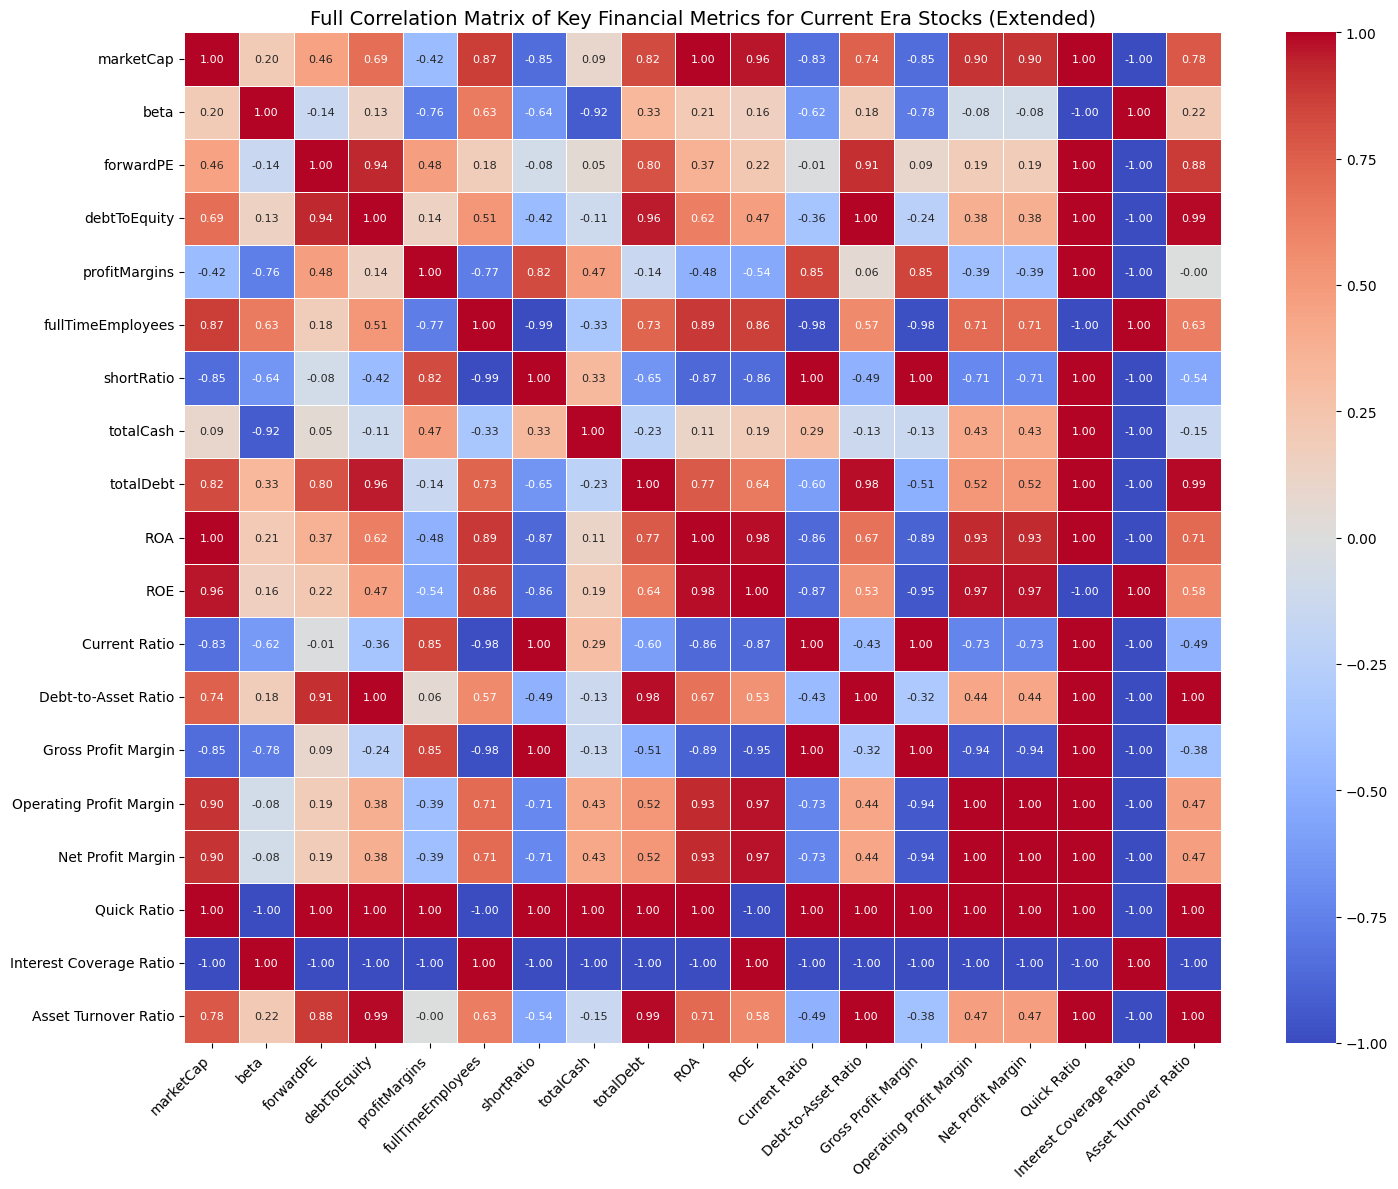

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure calculated_ratios_extended_df and df_financial_data_filtered are available
# If they are not (e.g., if this cell is run independently), re-run their creation cells.

# Combine the two dataframes. We'll use the 'Company' index from calculated_ratios_extended_df
# to align with the index of df_financial_data_filtered.

# Select numerical columns from df_financial_data_filtered
financial_metrics_filtered = df_financial_data_filtered[[
    'marketCap', 'beta', 'forwardPE', 'debtToEquity', 'profitMargins',
    'fullTimeEmployees', 'shortRatio', 'totalCash', 'totalDebt'
]].copy()

# Join with calculated_ratios_extended_df which contains all calculated ratios
# Ensure both dataframes have the same index (company names)
financial_metrics_combined = financial_metrics_filtered.join(calculated_ratios_extended_df)

# Drop any non-numeric columns that might have slipped in or columns with too many NaNs
financial_metrics_combined = financial_metrics_combined.select_dtypes(include=[float, int])

print("Combined Financial Metrics for Correlation Analysis (including extended ratios):")
display(financial_metrics_combined)

# Calculate the correlation matrix
correlation_matrix = financial_metrics_combined.corr()

print("\nFull Correlation Matrix (including extended ratios):")
display(correlation_matrix)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(15, 12)) # Adjusted figure size for more metrics
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8}) # Adjust font size for annotation
plt.title('Full Correlation Matrix of Key Financial Metrics for Current Era Stocks (Extended)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_25506/227764157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_25506/227764157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_25506/227764157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp

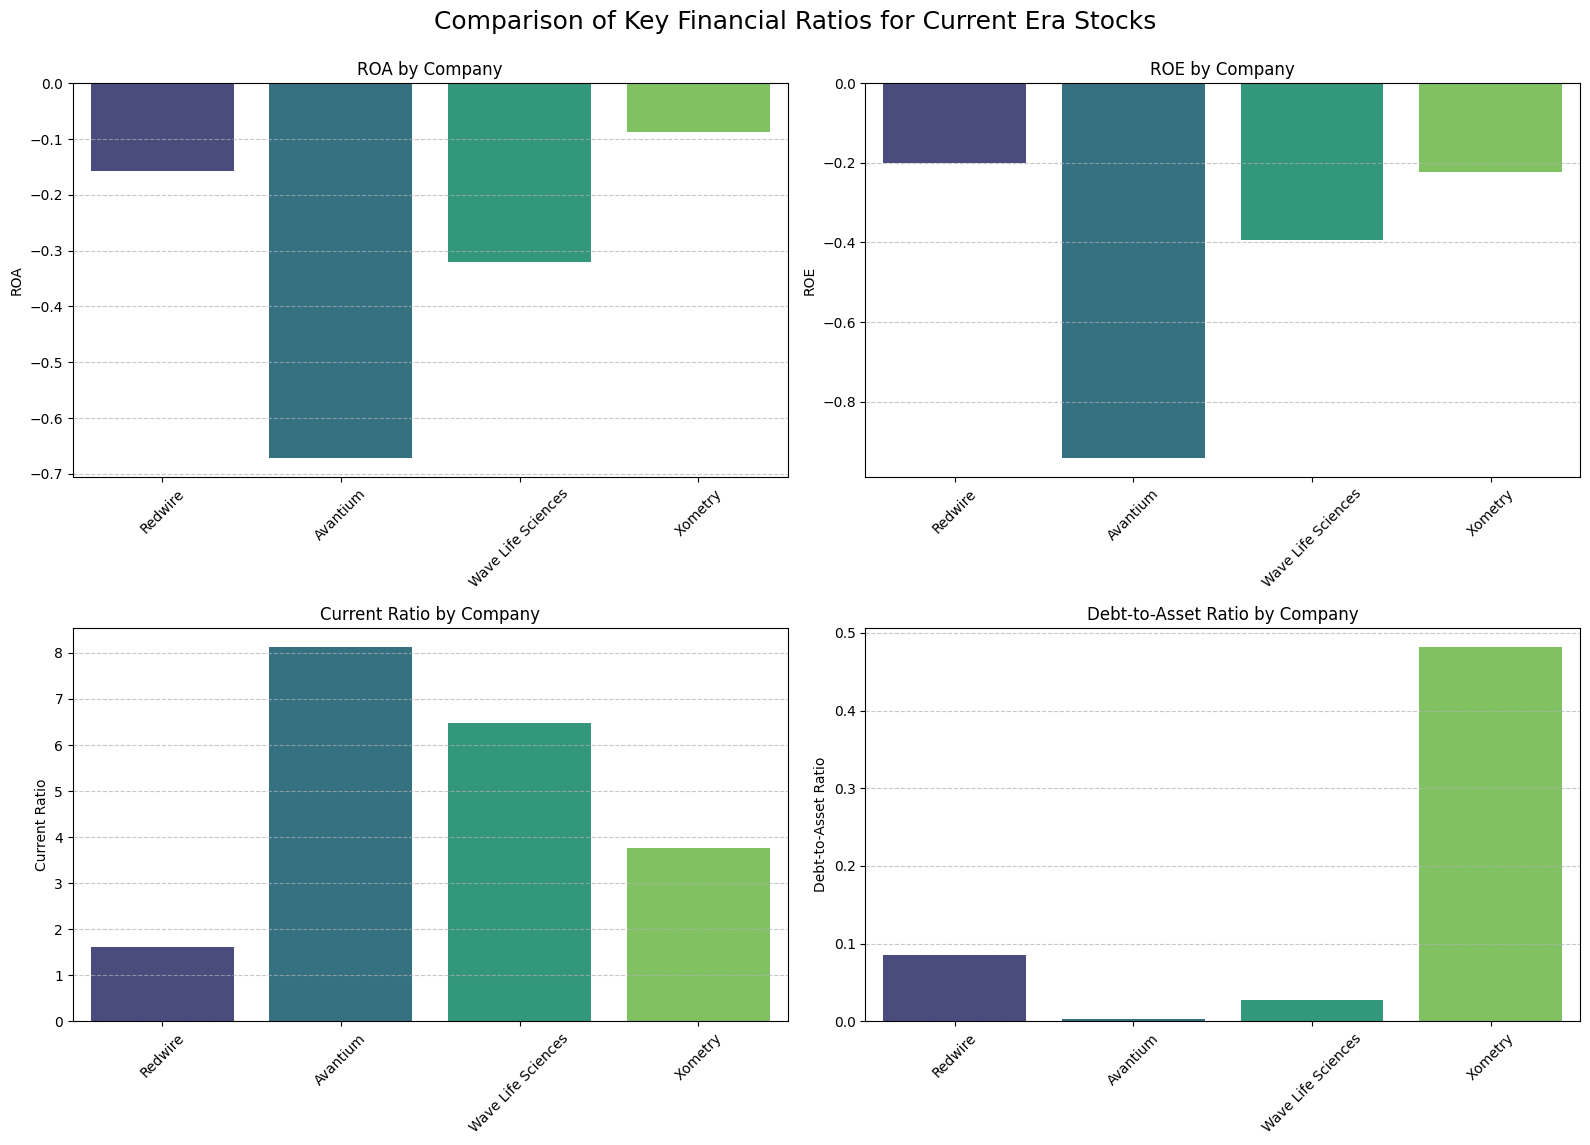

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

ratios_to_plot = ['ROA', 'ROE', 'Current Ratio', 'Debt-to-Asset Ratio']

for i, ratio in enumerate(ratios_to_plot):
    if ratio in calculated_ratios_df.columns:
        sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{ratio} by Company')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.suptitle('Comparison of Key Financial Ratios for Current Era Stocks', fontsize=18)
plt.show()

/tmp/ipykernel_25506/227764157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_25506/227764157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_25506/227764157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp

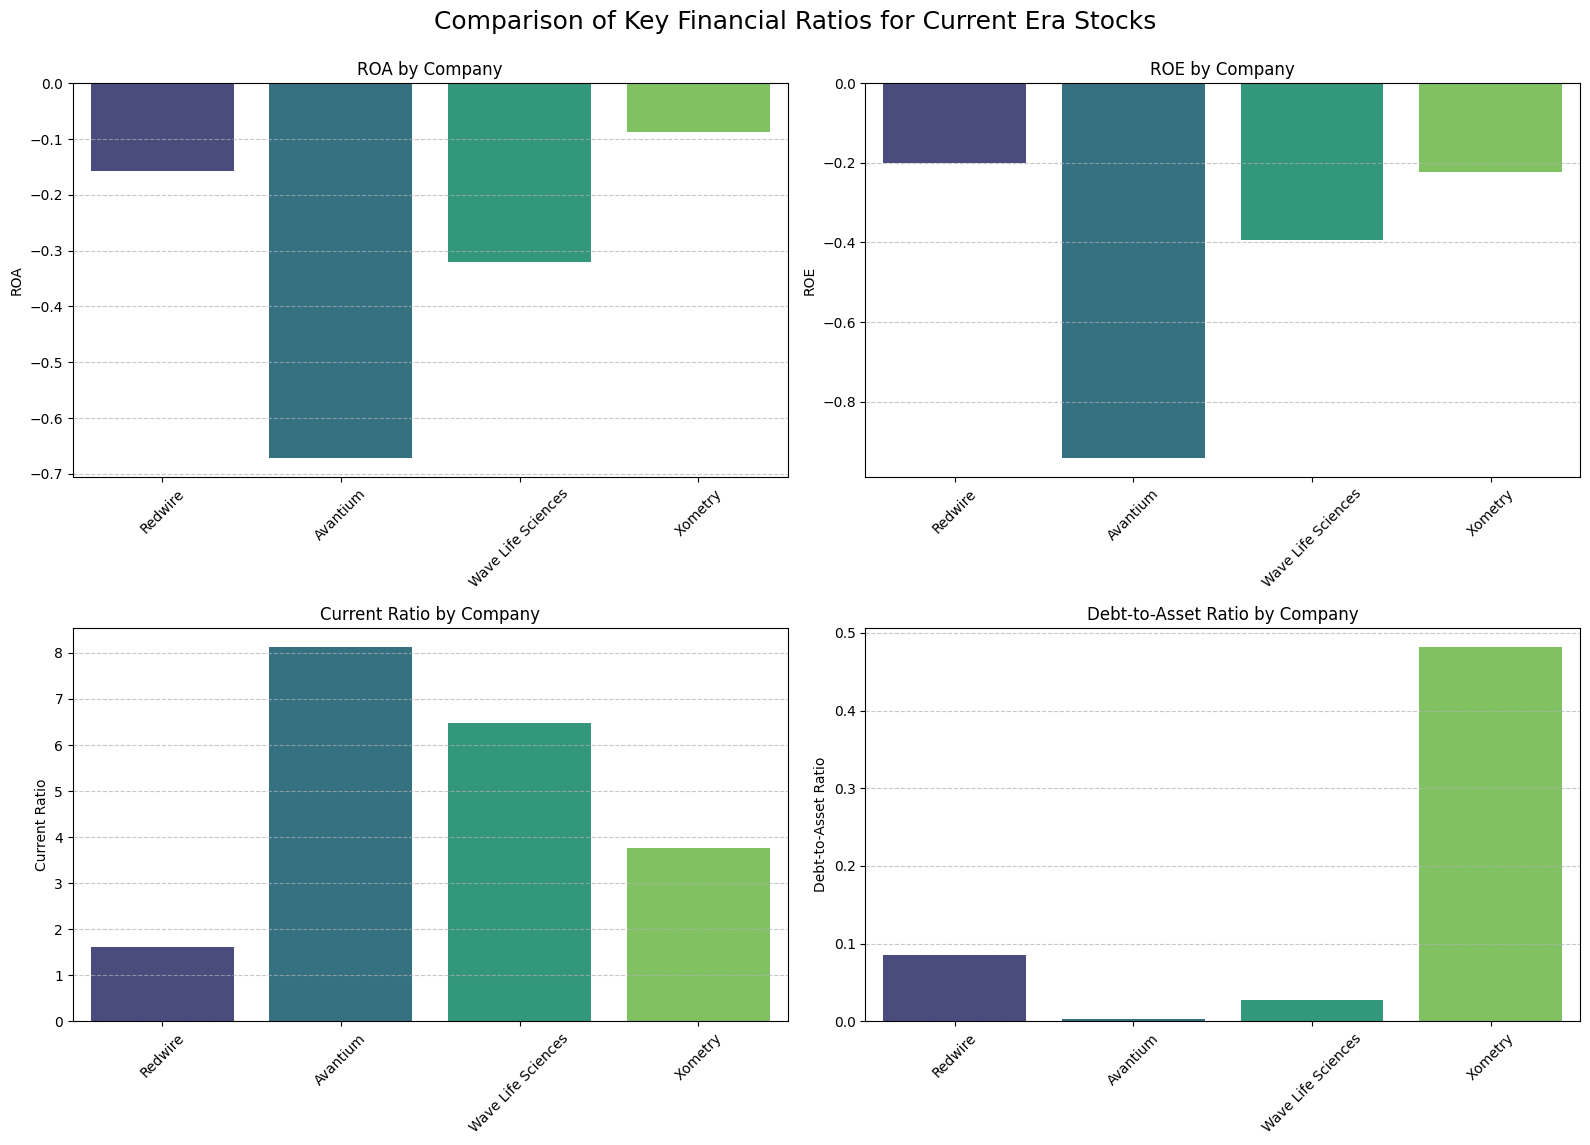

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

ratios_to_plot = ['ROA', 'ROE', 'Current Ratio', 'Debt-to-Asset Ratio']

for i, ratio in enumerate(ratios_to_plot):
    if ratio in calculated_ratios_df.columns:
        sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{ratio} by Company')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.suptitle('Comparison of Key Financial Ratios for Current Era Stocks', fontsize=18)
plt.show()

In [ ]:
# This cell is a duplicate of cell_0676a6bd and has been removed to avoid redundancy.

/tmp/ipykernel_25506/354103132.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_25506/354103132.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_25506/354103132.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
/tmp

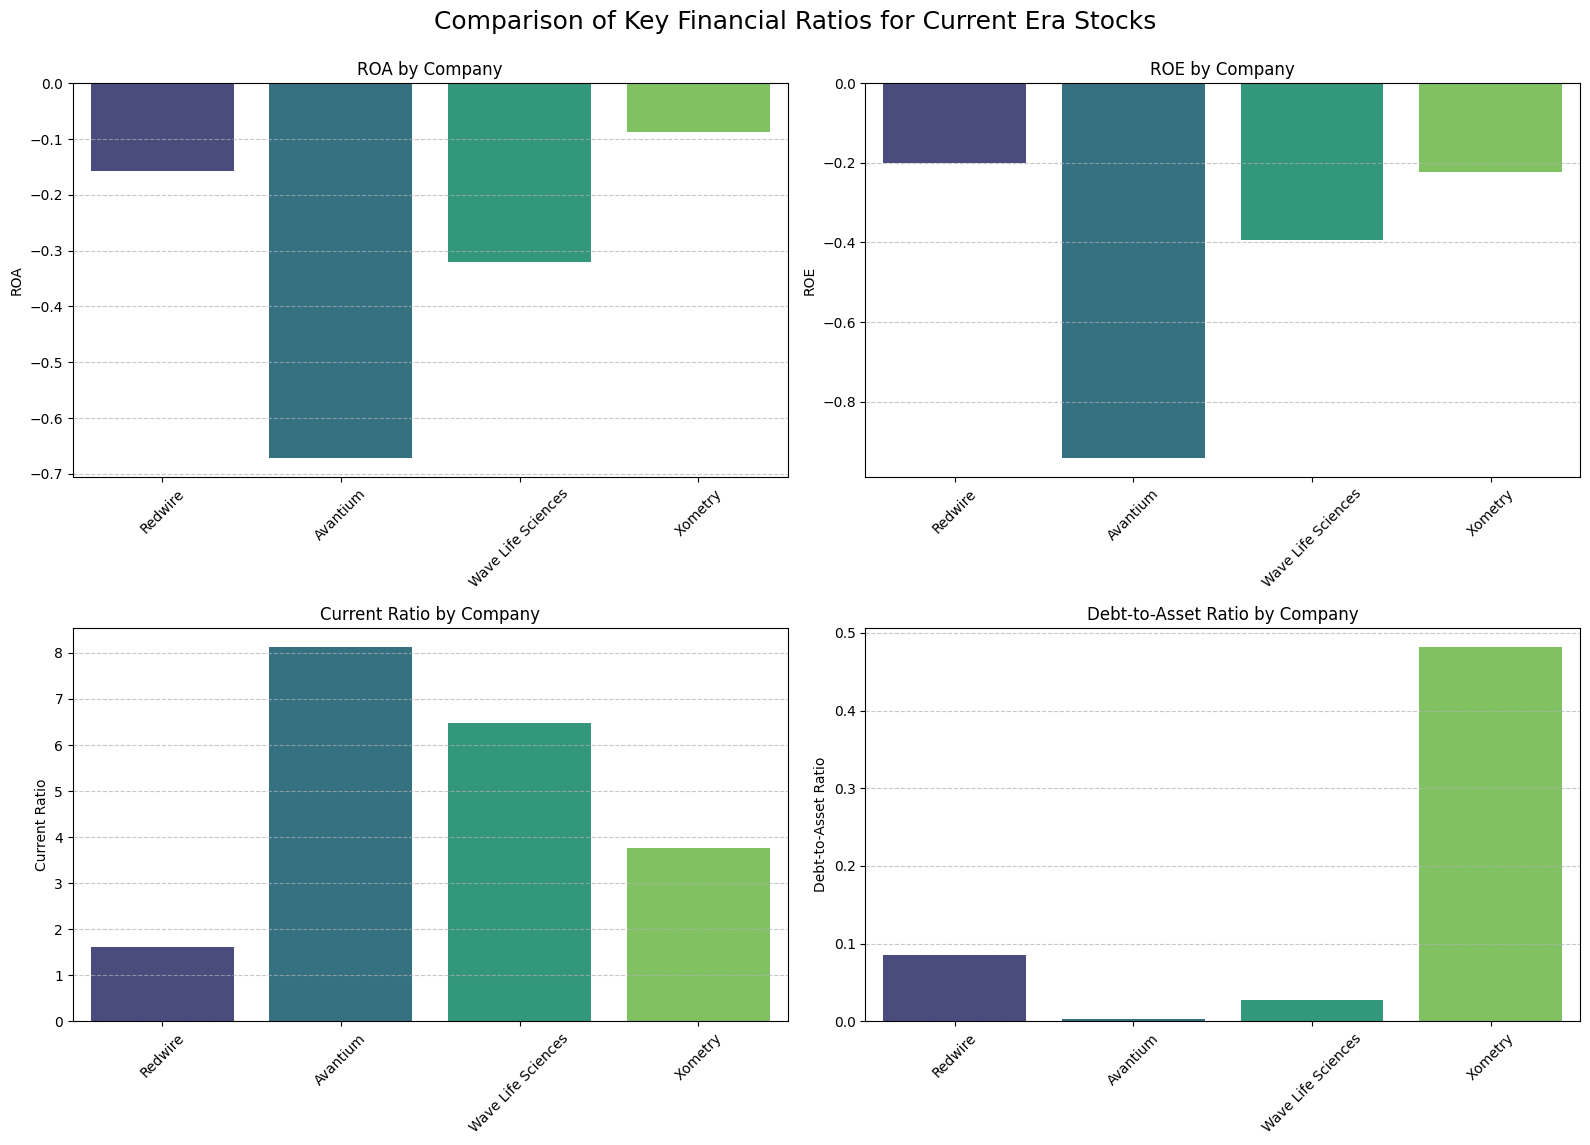

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

ratios_to_plot = ['ROA', 'ROE', 'Current Ratio', 'Debt-to-Asset Ratio']

for i, ratio in enumerate(ratios_to_plot):
    if ratio in calculated_ratios_df.columns:
        sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{ratio} by Company')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45) # Removed 'ha='right' here
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.suptitle('Comparison of Key Financial Ratios for Current Era Stocks', fontsize=18)
plt.show()

In [ ]:
# Install the Quandl library
!pip install Quandl

In [ ]:
import Quandl
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
NASDAQ_DATA_LINK_API_KEY = userdata.get('NASDAQ_DATA_LINK_API_KEY')

# Set the API key for Quandl
Quandl.ApiConfig.api_key = NASDAQ_DATA_LINK_API_KEY

print("\nAttempting to fetch a sample free dataset from Quandl (e.g., FRED/GDP)...")

try:
    # Try fetching a common free economic dataset, like US GDP from FRED
    # You might need to explore Quandl's website for other free codes.
    data = Quandl.get("FRED/GDP", authtoken=NASDAQ_DATA_LINK_API_KEY)

    if not data.empty:
        print(f"\nSample data from Quandl (FRED/GDP - first 5 rows):")
        display(data.head())
    else:
        print("No data found for FRED/GDP. Please check the dataset code and your API key.")
except Quandl.QuandlError as e:
    print(f"Error fetching data from Quandl: {e}")
    print("Please ensure your Nasdaq Data Link API key is valid and correctly entered in Colab secrets as 'NASDAQ_DATA_LINK_API_KEY'.")
    print("Also, verify that 'FRED/GDP' is still a publicly accessible dataset, or try another free dataset code from their website.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

ModuleNotFoundError: No module named 'Quandl'

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tickers for current era analysis
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

# List to store dictionaries of calculated financial ratios, including new ones
all_company_ratios_extended = []

print("\n--- Calculating extended financial ratios for current era stocks ---")

for company_name, ticker_symbol in current_era_tickers.items():
    print(f"\nProcessing {company_name} ({ticker_symbol})...")
    try:
        ticker = yf.Ticker(ticker_symbol)

        balance_sheet = ticker.balance_sheet
        financials = ticker.financials

        balance_sheet_T = balance_sheet.T
        financials_T = financials.T

        latest_bs = balance_sheet_T.iloc[0] if not balance_sheet_T.empty else pd.Series()
        latest_fin = financials_T.iloc[0] if not financials_T.empty else pd.Series()

        # --- Extract previously used components ---
        net_income = latest_fin.get('Net Income', np.nan)
        total_assets = latest_bs.get('Total Assets', np.nan)
        shareholder_equity = latest_bs.get('Stockholders Equity', latest_bs.get('Total Equity Gross Minority Interest', latest_bs.get('Share Holder Equity', np.nan)))
        current_assets = latest_bs.get('Current Assets', np.nan)
        current_liabilities = latest_bs.get('Current Liabilities', np.nan)

        total_debt_val = latest_bs.get('Total Debt', np.nan)
        if pd.isna(total_debt_val):
            current_debt = latest_bs.get('Current Debt And Capital Lease Obligation', np.nan)
            long_term_debt = latest_bs.get('Long Term Debt And Capital Lease Obligation', np.nan)
            if pd.isna(current_debt) and pd.isna(long_term_debt):
                total_debt_val = np.nan
            elif pd.isna(current_debt):
                total_debt_val = long_term_debt
            elif pd.isna(long_term_debt):
                total_debt_val = current_debt
            else:
                total_debt_val = current_debt + long_term_debt

        # --- Extract new components for additional ratios ---
        revenue = latest_fin.get('Total Revenue', latest_fin.get('Sales', np.nan))
        cogs = latest_fin.get('Cost Of Revenue', latest_fin.get('Cost of Goods Sold', np.nan))
        operating_income = latest_fin.get('Operating Income', np.nan)
        cash_equivalents = latest_bs.get('Cash And Cash Equivalents', np.nan)
        accounts_receivable = latest_bs.get('Receivables', np.nan)
        inventory = latest_bs.get('Inventory', np.nan)
        interest_expense = latest_fin.get('Interest Expense', np.nan)
        ebitda = latest_fin.get('EBITDA', np.nan) # Added EBITDA extraction

        # --- Calculate previously calculated Ratios ---
        calculated_ratios = {
            'Company': company_name,
            'ROA': (net_income / total_assets) if total_assets != 0 and not pd.isna(total_assets) else np.nan,
            'ROE': (net_income / shareholder_equity) if shareholder_equity != 0 and not pd.isna(shareholder_equity) else np.nan,
            'Current Ratio': (current_assets / current_liabilities) if current_liabilities != 0 and not pd.isna(current_liabilities) else np.nan,
            'Debt-to-Asset Ratio': (total_debt_val / total_assets) if total_assets != 0 and not pd.isna(total_assets) else np.nan
        }

        # --- Calculate additional Ratios ---
        gross_profit = revenue - cogs
        calculated_ratios['Gross Profit Margin'] = (gross_profit / revenue) * 100 if revenue != 0 and not pd.isna(revenue) else np.nan
        calculated_ratios['Operating Profit Margin'] = (operating_income / revenue) * 100 if revenue != 0 and not pd.isna(revenue) else np.nan
        calculated_ratios['Net Profit Margin'] = (net_income / revenue) * 100 if revenue != 0 and not pd.isna(revenue) else np.nan

        quick_assets = current_assets - inventory
        calculated_ratios['Quick Ratio'] = (quick_assets / current_liabilities) if current_liabilities != 0 and not pd.isna(current_liabilities) else np.nan

        calculated_ratios['Interest Coverage Ratio'] = (operating_income / interest_expense) if interest_expense != 0 and not pd.isna(interest_expense) else np.nan

        # Asset Turnover Ratio
        calculated_ratios['Asset Turnover Ratio'] = (revenue / total_assets) if total_assets != 0 and not pd.isna(total_assets) else np.nan
        calculated_ratios['EBITDA'] = ebitda # Add EBITDA to the dictionary
        calculated_ratios['Revenue'] = revenue # Add Revenue to the dictionary for direct access if needed for multiples

        all_company_ratios_extended.append(calculated_ratios)

    except Exception as e:
        print(f"  Error processing {company_name} ({ticker_symbol}) for extended ratio calculation: {e}")
        # Append a dictionary with NaNs for this company in case of an error
        all_company_ratios_extended.append({
            'Company': company_name,
            'ROA': np.nan, 'ROE': np.nan, 'Current Ratio': np.nan, 'Debt-to-Asset Ratio': np.nan,
            'Gross Profit Margin': np.nan, 'Operating Profit Margin': np.nan, 'Net Profit Margin': np.nan,
            'Quick Ratio': np.nan, 'Interest Coverage Ratio': np.nan, 'Asset Turnover Ratio': np.nan,
            'EBITDA': np.nan, 'Revenue': np.nan
        })

# Create the DataFrame from the list of dictionaries
calculated_ratios_extended_df = pd.DataFrame(all_company_ratios_extended).set_index('Company')

print("\n--- Calculated Extended Financial Ratios ---")
display(calculated_ratios_extended_df)


--- Calculating extended financial ratios for current era stocks ---

Processing Redwire (RDW)...

Processing Avantium (AVTX)...

Processing Wave Life Sciences (WVE)...

Processing Xometry (XMTR)...

--- Calculated Extended Financial Ratios ---


,ROA,ROE,Current Ratio,Debt-to-Asset Ratio,Gross Profit Margin,Operating Profit Margin,Net Profit Margin,Quick Ratio,Interest Coverage Ratio,Asset Turnover Ratio,EBITDA,Revenue
Company,,,,,,,,,,,,
Redwire,-0.156336,-0.199245,1.624610,0.085429,5.153840,-51.808540,-67.550636,1.265728,-4.376285,0.231435,-179223000.0,335381000.0
Avantium,-0.671993,-0.942323,8.136476,0.003366,100.000000,-123601.694915,-132642.372881,NaN,NaN,0.000507,-72581000.0,59000.0
Wave Life Sciences,-0.320091,-0.394280,6.467301,0.027825,NaN,-504.091090,-478.334543,NaN,NaN,0.066918,-206531000.0,42727000.0
Xometry,-0.087738,-0.224030,3.762751,0.482325,39.143732,-6.621752,-8.992166,3.718708,-9.265743,0.975716,-37502000.0,686631000.0


## Deeper Economic Integration: Linking Macro-Economics to Stock Performance

### Explanation

While we've focused on company-specific fundamentals and technical indicators, a truly comprehensive analysis integrates macroeconomic factors. These factors can significantly influence overall market sentiment, industry performance, and even individual company valuations.

**Measures for Deeper Economic Integration:**
*   **Inflation Rates:** High inflation can erode purchasing power and corporate profits, but also might lead to higher revenues in nominal terms. Central bank responses to inflation (e.g., interest rate hikes) directly impact borrowing costs and discount rates.
*   **Interest Rate Policies:** Set by central banks, interest rates affect the cost of capital for businesses, the attractiveness of debt versus equity, and the discount rates used in valuation models (like DCF).
*   **Unemployment Figures:** Reflect overall economic health. Low unemployment suggests strong consumer spending and economic growth, which can boost corporate earnings.
*   **Consumer Sentiment:** Surveys that gauge consumer confidence in the economy. High sentiment often translates to increased spending, benefiting businesses.

**Methodology for Linking Macro-Variables:**
Developing models to explicitly link these macroeconomic variables to stock performance or 'bubble' formation involves:
1.  **Regression Analysis:** Using historical macroeconomic data alongside stock prices or valuation multiples to identify correlations and causal relationships.
2.  **Factor Models:** Building models where macroeconomic factors (e.g., interest rate changes, inflation surprises) are considered systemic risks that influence a portfolio's or individual stock's returns.
3.  **Scenario Planning:** Assessing how different macroeconomic scenarios (e.g., recession, high inflation, rapid growth) would impact company valuations and stock prices.

**Challenge:** Direct, high-frequency, clean macroeconomic data can be challenging to source and integrate without specialized APIs or services. For illustration, we will conceptually discuss their impact rather than implementing a full data pull and modeling exercise for all of them.

## Advanced Investment Valuation & Risk Analysis

We will now delve into more sophisticated valuation metrics beyond P/E and P/B, specifically **EV/EBITDA** and **Price/Sales**, and then perform a simplified **Discounted Cash Flow (DCF)** analysis. We will also discuss advanced risk analysis and portfolio optimization conceptually.

### Valuation Multiple 1: Enterprise Value to EBITDA (EV/EBITDA)

**Explanation:**
EV/EBITDA (Enterprise Value to Earnings Before Interest, Taxes, Depreciation, and Amortization) is a popular valuation multiple used to compare the value of a company, debt included, to its cash operating earnings. It's often preferred over P/E for several reasons:
*   **Capital Structure Neutral:** Enterprise Value considers both equity and debt, making it comparable across companies with different financing structures.
*   **Non-Cash Charges Neutral:** EBITDA excludes non-cash expenses (depreciation and amortization), which can vary widely due to accounting policies, making it a cleaner measure of operational profitability.
*   **Tax Neutral:** It's pre-tax, removing the impact of differing tax rates.

**Formula:**
$$\text{Enterprise Value (EV)} = \text{Market Capitalization} + \text{Total Debt} - \text{Cash & Cash Equivalents}$$
$$\text{EV/EBITDA Ratio} = \frac{\text{Enterprise Value}}{\text{EBITDA}}$$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_financial_data_filtered and calculated_ratios_extended_df are available
# Re-create if necessary based on your current state, assuming they exist.

# Combine dataframes for marketCap, totalDebt, totalCash and EBITDA
# Start with marketCap from df_financial_data_filtered
valuation_data = df_financial_data_filtered[['marketCap', 'totalDebt', 'totalCash']].copy()

# Merge with calculated_ratios_extended_df for EBITDA and Revenue
valuation_data = valuation_data.join(calculated_ratios_extended_df[['EBITDA', 'Revenue']])

# Calculate Enterprise Value (EV)
valuation_data['Enterprise Value'] = valuation_data['marketCap'] + valuation_data['totalDebt'] - valuation_data['totalCash']

# Calculate EV/EBITDA
# Handle potential division by zero or NaN for EBITDA
valuation_data['EV/EBITDA'] = valuation_data.apply(lambda row:
    row['Enterprise Value'] / row['EBITDA'] if row['EBITDA'] != 0 and not pd.isna(row['EBITDA']) and not pd.isna(row['Enterprise Value'])
    else np.nan, axis=1)

print("Valuation Data with EV/EBITDA:")
display(valuation_data[['marketCap', 'totalDebt', 'totalCash', 'EBITDA', 'Enterprise Value', 'EV/EBITDA']])

# Plotting EV/EBITDA
plt.figure(figsize=(10, 6))
sns.barplot(x=valuation_data.index, y='EV/EBITDA', data=valuation_data, palette='viridis')
plt.title('Enterprise Value to EBITDA (EV/EBITDA) by Company')
plt.xlabel('Company')
plt.ylabel('EV/EBITDA Ratio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Valuation Multiple 2: Price/Sales (P/S) Ratio

**Explanation:**
Price/Sales (P/S) Ratio compares a company's stock price to its revenue per share. It is particularly useful for valuing:
*   **Growth Companies:** Especially those that are not yet profitable, as it focuses on top-line revenue growth rather than earnings.
*   **Cyclical Industries:** Where earnings can be highly volatile, revenue tends to be more stable.
*   **Distressed Companies:** When earnings are negative, P/E ratios are meaningless, but P/S can still provide a valuation benchmark.

**Formula:**
$$\text{Price/Sales Ratio} = \frac{\text{Market Capitalization}}{\text{Total Revenue}}$$

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Price/Sales Ratio
# We already have 'marketCap' from df_financial_data_filtered and 'Revenue' in valuation_data (from calculated_ratios_extended_df)

valuation_data['Price/Sales'] = valuation_data.apply(lambda row:
    row['marketCap'] / row['Revenue'] if row['Revenue'] != 0 and not pd.isna(row['Revenue']) and not pd.isna(row['marketCap'])
    else np.nan, axis=1)

print("Valuation Data with Price/Sales:")
display(valuation_data[['marketCap', 'Revenue', 'Price/Sales']])

# Plotting Price/Sales
plt.figure(figsize=(10, 6))
sns.barplot(x=valuation_data.index, y='Price/Sales', data=valuation_data, palette='rocket')
plt.title('Price/Sales (P/S) Ratio by Company')
plt.xlabel('Company')
plt.ylabel('Price/Sales Ratio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Intrinsic Valuation: Discounted Cash Flow (DCF)

**Explanation:**
Discounted Cash Flow (DCF) analysis is an intrinsic valuation method used to estimate the value of an investment based on its expected future cash flows. The core principle is that an asset's value is the present value of its future cash flows, discounted at a rate that reflects the riskiness of those cash flows.

**Key Steps in a DCF Model:**
1.  **Project Free Cash Flows (FCF):** Forecast the company's FCF for a explicit forecast period (e.g., 5-10 years). FCF is typically calculated as: `EBIT * (1 - Tax Rate) + Depreciation & Amortization - Capital Expenditures - Change in Working Capital`.
2.  **Estimate Terminal Value (TV):** This represents the value of the company's cash flows beyond the explicit forecast period. It's often calculated using a perpetuity growth model or an exit multiple.
3.  **Determine the Discount Rate:** This is typically the Weighted Average Cost of Capital (WACC), which represents the average rate of return a company expects to pay to all its security holders to finance its assets.
4.  **Discount Future Cash Flows & Terminal Value:** Calculate the present value of the projected FCFs and the Terminal Value using the WACC.
5.  **Sum Present Values:** The sum of these present values gives the intrinsic value of the operating assets.
6.  **Calculate Equity Value:** Adjust for net debt and minority interests to arrive at the equity value, then divide by shares outstanding to get per-share intrinsic value.

**Simplified DCF Calculation (Conceptual Example):**
Implementing a full-fledged DCF model requires detailed projections of revenues, expenses, capital expenditures, and working capital, which is beyond the scope of a quick demonstration here. However, I can illustrate the *concept* with a highly simplified example, making assumptions for growth rates and WACC.

For a realistic DCF, we would need: Historical financials (income statements, balance sheets, cash flow statements), management guidance, industry trends, and more granular data than readily available through `yfinance.Ticker().info` for robust projections. For this illustration, we will use simplified assumptions to calculate a conceptual FCF and WACC.

**Assumptions for our simplified example:**
*   **FCF Growth Rate (Explicit Period):** We'll assume a modest growth rate for the next 5 years.
*   **Terminal Growth Rate (Perpetuity):** A very low, stable growth rate for cash flows beyond the explicit forecast period.
*   **WACC (Discount Rate):** A generic WACC as a placeholder. A proper WACC calculation involves calculating the cost of equity (using CAPM) and cost of debt, weighted by their proportion in the capital structure.

Given the complexity, we'll demonstrate a simplified calculation for one company and discuss the methodology rather than plotting a full DCF output, as the plot would largely be based on many assumptions.

In [ ]:
import pandas as pd
import numpy as np

# Let's perform a highly simplified DCF for one company, e.g., Xometry (XMTR)
company_name = 'Xometry'
ticker_symbol = current_era_tickers[company_name]

# Fetch current market data for shares outstanding and current price
# We'll need to re-fetch ticker info as df_financial_data_filtered might not have shares outstanding
company_info = yf.Ticker(ticker_symbol).info
shares_outstanding = company_info.get('sharesOutstanding')
current_price = company_info.get('currentPrice')

# Get latest EBITDA and Revenue from our calculated_ratios_extended_df
latest_ebitda = calculated_ratios_extended_df.loc[company_name, 'EBITDA']
latest_revenue = calculated_ratios_extended_df.loc[company_name, 'Revenue']

# --- Simplified DCF Assumptions (for demonstration purposes only) ---
forecast_years = 5
# Assuming a placeholder for tax rate and capital expenditure/working capital changes for FCF calculation
# In a real DCF, these would be projected in detail.
simplified_tax_rate = 0.21 # Example tax rate
simplified_capex_n_wc = 0.05 # 5% of revenue for Capex + WC changes (negative impact on FCF)

# FCF Growth Rate for the explicit forecast period (e.g., 5 years)
fcf_growth_rate = 0.08 # 8% annual growth for demonstration

# Terminal Growth Rate (perpetuity growth rate)
terminal_growth_rate = 0.02 # 2% long-term stable growth

# Discount Rate (WACC - Weighted Average Cost of Capital)
# A real WACC calculation is complex, involving Cost of Equity (CAPM) and Cost of Debt
wacc = 0.10 # 10% WACC for demonstration

print(f"--- Simplified DCF Model for {company_name} ({ticker_symbol}) ---")
print(f"Latest EBITDA: ${latest_ebitda:,.0f}")
print(f"Latest Revenue: ${latest_revenue:,.0f}")
print(f"Shares Outstanding: {shares_outstanding:,.0f}")
print(f"Current Share Price: ${current_price:,.2f}\n")

# --- Step 1: Project Free Cash Flows (highly simplified) ---
# Let's assume FCF is a simplified proxy based on a portion of EBITDA or Revenue
# For this example, let's assume FCF = (EBITDA * (1 - tax_rate)) - a portion of revenue for CapEx/WC
# This is a significant simplification; actual FCF forecasting is more complex.

# Estimate current FCF (very simplified for illustration)
# Assuming a placeholder for non-cash expenses being covered by D&A, and a general tax on operating profit.
# A more rigorous FCF would come from a full financial model.
current_fcf_proxy = (latest_ebitda * (1 - simplified_tax_rate)) - (latest_revenue * simplified_capex_n_wc)

# Handle negative current FCF, as growth models might not apply directly or need careful interpretation
if current_fcf_proxy < 0:
    print("Warning: Estimated current FCF is negative. DCF assumptions for growth may need re-evaluation.")
    # For this conceptual example, we will proceed, but in reality, a negative FCF requires deeper analysis
    # or a different valuation approach.


projected_fcf = []
for i in range(1, forecast_years + 1):
    fcf_year = current_fcf_proxy * ((1 + fcf_growth_rate) ** i)
    projected_fcf.append(fcf_year)

# --- Step 2: Estimate Terminal Value (TV) ---
# FCF in the year after the explicit forecast period
fcf_year_n_plus_1 = projected_fcf[-1] * (1 + terminal_growth_rate)

terminal_value = fcf_year_n_plus_1 / (wacc - terminal_growth_rate)

# --- Step 3 & 4: Discount Future Cash Flows & Terminal Value ---
present_value_fcf = []
for i, fcf in enumerate(projected_fcf):
    pv = fcf / ((1 + wacc) ** (i + 1))
    present_value_fcf.append(pv)

present_value_terminal_value = terminal_value / ((1 + wacc) ** forecast_years)

# --- Step 5: Sum Present Values (Enterprise Value) ---
ent_value = sum(present_value_fcf) + present_value_terminal_value

# --- Step 6: Calculate Equity Value and Intrinsic Value Per Share ---
# Fetch total debt and total cash from valuation_data
total_debt = valuation_data.loc[company_name, 'totalDebt']
total_cash = valuation_data.loc[company_name, 'totalCash']

equity_value = ent_value - total_debt + total_cash

# Ensure shares_outstanding is not zero or NaN before division
if shares_outstanding and shares_outstanding != 0 and not pd.isna(shares_outstanding):
    intrinsic_value_per_share = equity_value / shares_outstanding
else:
    intrinsic_value_per_share = np.nan

print("\n--- DCF Results (Highly Simplified & Illustrative) ---")
print(f"Projected FCFs (Years 1-{forecast_years}): {[f'${fcf:,.0f}' for fcf in projected_fcf]}")
print(f"Sum of PV of FCFs: ${sum(present_value_fcf):,.0f}")
print(f"Terminal Value (TV): ${terminal_value:,.0f}")
print(f"PV of Terminal Value: ${present_value_terminal_value:,.0f}")
print(f"Calculated Enterprise Value: ${ent_value:,.0f}")
print(f"Calculated Equity Value: ${equity_value:,.0f}")

if not pd.isna(intrinsic_value_per_share):
    print(f"Intrinsic Value Per Share (DCF): ${intrinsic_value_per_share:,.2f}")
    print(f"Current Market Price: ${current_price:,.2f}")
    if current_price < intrinsic_value_per_share:
        print("\nBased on this simplified DCF, the stock appears potentially UNDERVALUED.")
    elif current_price > intrinsic_value_per_share:
        print("\nBased on this simplified DCF, the stock appears potentially OVERVALUED.")
    else:
        print("\nBased on this simplified DCF, the stock appears FAIRLY VALUED.")
else:
    print("Could not calculate Intrinsic Value Per Share due to missing shares outstanding.")


# Plotting FCF projections for visualization (optional, for explicit period)
plt.figure(figsize=(10, 6))
plt.bar(range(1, forecast_years + 1), projected_fcf, color='skyblue')
plt.title(f'Projected Free Cash Flows for {company_name} (Simplified DCF)')
plt.xlabel('Forecast Year')
plt.ylabel('Free Cash Flow ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Advanced Risk Metrics (Conceptual)

**Explanation:**
While our current analysis touches upon risk through 'beta' (market risk), advanced risk metrics provide a more granular and sophisticated view of potential losses.

*   **Value at Risk (VaR):** VaR quantifies the potential loss in value of a portfolio or asset over a defined period for a given confidence interval. For example, a 95% VaR of $1 million over one day means there's a 5% chance the portfolio could lose more than $1 million in a single day.
*   **Conditional VaR (CVaR) / Expected Shortfall:** CVaR is a more conservative risk measure than VaR. It quantifies the expected loss *given that* the loss exceeds the VaR threshold. It gives an idea of the average loss in the 'worst-case' scenarios, whereas VaR only tells you the threshold you're unlikely to exceed.
*   **Credit Risk Models:** These models assess the likelihood of a borrower defaulting on debt obligations. They involve analyzing financial ratios, industry trends, macroeconomic factors, and proprietary credit scoring systems.
*   **Monte Carlo Simulation for Future Price Paths:** This methodology involves running numerous simulations of future stock price movements based on various probability distributions for key variables (e.g., volatility, drift). It can help estimate the probability of achieving certain returns, the distribution of future outcomes, and more robust VaR/CVaR calculations.

**Implementation Note:** Implementing these metrics requires significant historical data, statistical modeling expertise, and often specialized software/libraries. They are highly complex and beyond a straightforward demonstration in this environment.

### Portfolio Optimization Concepts (Conceptual)

**Explanation:**
After analyzing individual stocks, the next step in investment strategy is often to combine them into a portfolio. Portfolio optimization aims to construct a portfolio that maximizes expected return for a given level of risk, or minimizes risk for a given expected return.

*   **Modern Portfolio Theory (MPT):** Developed by Harry Markowitz, MPT suggests that investors can construct portfolios to optimize expected return for a given level of market risk, by selecting assets with varying risk-return characteristics and how they covary (correlate) with each other. The core idea is diversification, where combining assets whose returns are not perfectly correlated can reduce overall portfolio risk without sacrificing expected returns.
    *   **Efficient Frontier:** A key concept in MPT, representing the set of optimal portfolios that offer the highest expected return for a defined level of risk, or the lowest risk for a given expected return.
*   **Capital Asset Pricing Model (CAPM):** CAPM describes the relationship between systematic risk (beta) and expected return for assets, particularly stocks. It suggests that the expected return of an asset is equal to the risk-free rate plus a risk premium, where the risk premium is proportional to the asset's beta. It's a foundational model for determining the required rate of return for an asset or equity.
    *   **Formula:** $$E(R_i) = R_f + \beta_i (E(R_m) - R_f)$$
        Where:
        *   $E(R_i)$ = Expected return on asset i
        *   $R_f$ = Risk-free rate
        *   $\beta_i$ = Beta of asset i (measure of systematic risk)
        *   $E(R_m)$ = Expected market return
        *   $(E(R_m) - R_f)$ = Market risk premium

**Implementation Note:** Implementing MPT involves historical return and covariance data for a selection of assets, solving optimization problems, and is usually done with specialized libraries (e.g., `PyPortfolioOpt`). CAPM's primary application is in determining the cost of equity for WACC calculations or assessing if an asset is mispriced relative to its risk.

## Specialized Banking Analysis (Conceptual)

**Explanation:**
While we defined several banking-specific ratios (Net Interest Margin, Tier 1 Capital Ratio, Non-Performing Loan Ratio, Cost-to-Income Ratio), our current set of companies (Redwire, Avantium, Wave Life Sciences, Xometry) are not financial institutions. Therefore, applying these metrics directly would be inappropriate and yield meaningless results.

**Relevance if Applicable:**
If we were analyzing a bank or other financial services firm, these ratios would be absolutely critical:
*   **Net Interest Margin (NIM):** A primary profitability metric for banks, showing how efficiently they convert interest-bearing assets into net interest income.
*   **Tier 1 Capital Ratio:** A key indicator of a bank's financial strength and ability to absorb losses, mandated by regulatory bodies like Basel Accords.
*   **Non-Performing Loan (NPL) Ratio:** Reveals the quality of a bank's loan book and its exposure to potential credit losses. High NPLs signal distress.
*   **Cost-to-Income Ratio:** Measures a bank's operational efficiency, indicating how well it controls operating expenses relative to its income.

**Methodology for Banking Analysis:**
Analyzing banks requires a deep dive into their balance sheets (loans, deposits, reserves), income statements (interest income, interest expense, non-interest income), and off-balance-sheet items. Regulators have specific reporting requirements for banks (e.g., Call Reports in the U.S.) that differ from typical industrial companies, making specialized data sources often necessary.

## Alternative 'Bubble' Indicators & Advanced Technical Analysis

Beyond our `(Price - 50-day SMA) / 20-day SMA` 'Bubble Indicator', there are numerous other technical indicators and broader market measures that can signal overbought/oversold conditions or potential speculative excesses.

### Alternative Technical Indicator: Relative Strength Index (RSI)

**Explanation:**
The Relative Strength Index (RSI) is a momentum oscillator developed by J. Welles Wilder Jr. that measures the speed and change of price movements. RSI oscillates between zero and 100.

*   **Interpretation:** Traditionally, RSI is considered overbought when above 70 and oversold when below 30. These signals suggest that an asset's price has risen or fallen too much and may be due for a correction.
*   **Divergence:** Bullish divergence occurs when the price makes a lower low, but RSI makes a higher low, suggesting weakening downward momentum. Bearish divergence occurs when the price makes a higher high, but RSI makes a lower high, suggesting weakening upward momentum.

**Formula:**
$$\text{RSI} = 100 - \frac{100}{1 + \text{RS}}$$
Where:
$$\text{RS} = \frac{\text{Average Gain}}{\text{Average Loss}}$$

(Average Gain and Average Loss are calculated over a specified period, typically 14 periods for daily charts).

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Tickers for current era analysis
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

RSI_PERIOD = 14

plt.figure(figsize=(15, 10))
plt.suptitle(f'Relative Strength Index (RSI - {RSI_PERIOD} periods) for Current Era Stocks', y=1.02, fontsize=16)

plot_idx = 1
for company_name, ticker_symbol in current_era_tickers.items():
    try:
        # Fetch historical data (e.g., last 2 years)
        data = yf.download(ticker_symbol, period="2y", interval="1d")

        if data.empty:
            print(f"No historical data found for {company_name} ({ticker_symbol}). Skipping RSI calculation.")
            continue

        price_series = data['Adj Close'].squeeze() if 'Adj Close' in data.columns else data['Close'].squeeze()

        # Calculate daily price changes
        delta = price_series.diff()

        # Calculate gains (positive changes) and losses (negative changes)
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)

        # Calculate average gain and average loss (using EWMA for smoothing, common for RSI)
        avg_gain = gain.ewm(com=RSI_PERIOD - 1, min_periods=RSI_PERIOD).mean()
        avg_loss = loss.ewm(com=RSI_PERIOD - 1, min_periods=RSI_PERIOD).mean()

        # Calculate Relative Strength (RS)
        rs = avg_gain / avg_loss

        # Calculate RSI
        data['RSI'] = 100 - (100 / (1 + rs))

        # Plotting
        ax = plt.subplot(2, 2, plot_idx)
        ax.plot(data.index, data['RSI'], label='RSI', color='purple')
        ax.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
        ax.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
        ax.set_title(f'{company_name} ({ticker_symbol}) RSI')
        ax.set_xlabel('Date')
        ax.set_ylabel('RSI Value')
        ax.set_ylim(0, 100) # RSI typically ranges from 0 to 100
        ax.legend()
        ax.grid(True)

        plot_idx += 1

    except Exception as e:
        print(f"Error calculating or plotting RSI for {company_name} ({ticker_symbol}): {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Alternative Technical Indicator: Bollinger Bands

**Explanation:**
Bollinger Bands, developed by John Bollinger, are volatility bands placed above and below a simple moving average. The bands are based on standard deviation and adjust to market volatility: they widen during periods of high volatility and contract during periods of low volatility.

*   **Upper Band:** Typically 2 standard deviations above the 20-period SMA.
*   **Lower Band:** Typically 2 standard deviations below the 20-period SMA.
*   **Middle Band:** Usually a 20-period Simple Moving Average (SMA).

**Interpretation:**
*   **Overbought/Oversold Signals:** When prices touch or exceed the upper band, the asset may be overbought. When prices touch or fall below the lower band, it may be oversold. This is often used in conjunction with other indicators.
*   **Volatility Contraction and Expansion:** A squeeze (bands narrowing) often foreshadows a significant price movement. An expansion (bands widening) indicates increasing volatility and can accompany strong trends.
*   **Trend Confirmation:** During strong uptrends, prices tend to ride the upper band. During strong downtrends, they tend to ride the lower band.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Tickers for current era analysis
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

BB_PERIOD = 20 # Typically 20 periods for SMA and Standard Deviation
BB_STD_DEV = 2 # Typically 2 standard deviations

plt.figure(figsize=(15, 10))
plt.suptitle(f'Bollinger Bands ({BB_PERIOD} periods, {BB_STD_DEV} std dev) for Current Era Stocks', y=1.02, fontsize=16)

plot_idx = 1
for company_name, ticker_symbol in current_era_tickers.items():
    try:
        # Fetch historical data (e.g., last 2 years)
        data = yf.download(ticker_symbol, period="2y", interval="1d")

        if data.empty:
            print(f"No historical data found for {company_name} ({ticker_symbol}). Skipping Bollinger Bands calculation.")
            continue

        price_series = data['Adj Close'].squeeze() if 'Adj Close' in data.columns else data['Close'].squeeze()

        # Calculate Middle Band (SMA)
        data['SMA'] = price_series.rolling(window=BB_PERIOD).mean()

        # Calculate Standard Deviation
        data['STD_DEV'] = price_series.rolling(window=BB_PERIOD).std()

        # Calculate Upper and Lower Bands
        data['Upper_Band'] = data['SMA'] + (data['STD_DEV'] * BB_STD_DEV)
        data['Lower_Band'] = data['SMA'] - (data['STD_DEV'] * BB_STD_DEV)

        # Plotting
        ax = plt.subplot(2, 2, plot_idx)
        ax.plot(data.index, price_series, label='Close Price', color='blue', alpha=0.7)
        ax.plot(data.index, data['SMA'], label=f'{BB_PERIOD}-day SMA', color='orange', linestyle='--', alpha=0.7)
        ax.plot(data.index, data['Upper_Band'], label='Upper Band', color='red', linestyle=':', alpha=0.7)
        ax.plot(data.index, data['Lower_Band'], label='Lower Band', color='green', linestyle=':', alpha=0.7)
        ax.set_title(f'{company_name} ({ticker_symbol}) Bollinger Bands')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        ax.grid(True)

        plot_idx += 1

    except Exception as e:
        print(f"Error calculating or plotting Bollinger Bands for {company_name} ({ticker_symbol}): {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Alternative Technical Indicator: Moving Average Convergence Divergence (MACD)

**Explanation:**
Moving Average Convergence Divergence (MACD) is a trend-following momentum indicator developed by Gerald Appel that shows the relationship between two moving averages of a security’s price. It consists of three components:

*   **MACD Line:** The difference between a 12-period Exponential Moving Average (EMA) and a 26-period EMA.
*   **Signal Line:** A 9-period EMA of the MACD Line.
*   **Histogram:** The difference between the MACD Line and the Signal Line.

**Interpretation:**
*   **Crossovers:** A bullish signal is generated when the MACD Line crosses above the Signal Line. A bearish signal occurs when the MACD Line crosses below the Signal Line.
*   **Divergence:** Divergence between the MACD and price action (e.g., price makes a higher high, but MACD makes a lower high) can signal a potential reversal.
*   **Centerline Crossovers:** When the MACD Line crosses above zero, it indicates bullish momentum. Below zero, it indicates bearish momentum.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Tickers for current era analysis
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

SHORT_EMA = 12
LONG_EMA = 26
SIGNAL_EMA = 9

plt.figure(figsize=(15, 10))
plt.suptitle('Moving Average Convergence Divergence (MACD) for Current Era Stocks', y=1.02, fontsize=16)

plot_idx = 1
for company_name, ticker_symbol in current_era_tickers.items():
    try:
        # Fetch historical data (e.g., last 2 years)
        data = yf.download(ticker_symbol, period="2y", interval="1d")

        if data.empty:
            print(f"No historical data found for {company_name} ({ticker_symbol}). Skipping MACD calculation.")
            continue

        price_series = data['Adj Close'].squeeze() if 'Adj Close' in data.columns else data['Close'].squeeze()

        # Calculate EMAs
        data['EMA_Short'] = price_series.ewm(span=SHORT_EMA, adjust=False).mean()
        data['EMA_Long'] = price_series.ewm(span=LONG_EMA, adjust=False).mean()

        # Calculate MACD Line
        data['MACD_Line'] = data['EMA_Short'] - data['EMA_Long']

        # Calculate Signal Line
        data['Signal_Line'] = data['MACD_Line'].ewm(span=SIGNAL_EMA, adjust=False).mean()

        # Calculate MACD Histogram
        data['MACD_Histogram'] = data['MACD_Line'] - data['Signal_Line']

        # Plotting
        ax = plt.subplot(2, 2, plot_idx) # MACD plots
        ax.plot(data.index, data['MACD_Line'], label='MACD Line', color='blue')
        ax.plot(data.index, data['Signal_Line'], label='Signal Line', color='red', linestyle='--')
        ax.bar(data.index, data['MACD_Histogram'], label='Histogram', color='gray', alpha=0.6)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(f'{company_name} ({ticker_symbol}) MACD')
        ax.set_xlabel('Date')
        ax.set_ylabel('MACD Value')
        ax.legend()
        ax.grid(True)

        plot_idx += 1

    except Exception as e:
        print(f"Error calculating or plotting MACD for {company_name} ({ticker_symbol}): {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Other Technical Indicators (Conceptual)

*   **Bollinger Bands:** Developed by John Bollinger, these are volatility bands placed above and below a simple moving average. The bands expand and contract based on market volatility, helping to identify overbought/oversold conditions relative to the average, and potential price reversals when price touches or breaks the bands.
*   **Moving Average Convergence Divergence (MACD):** A trend-following momentum indicator that shows the relationship between two moving averages of a security’s price. It consists of the MACD line (difference between two EMAs), a signal line (EMA of the MACD line), and a histogram (difference between MACD and signal lines). Traders look for crossovers, divergences, and rapid rises/falls to generate signals.

**Macro-level Bubble Indicators (Conceptual):**
These indicators assess potential bubble conditions across entire markets or economies, rather than individual stocks.

*   **Market Capitalization to GDP:** Often referred to as the 'Buffett Indicator,' this compares the total market value of all publicly traded stocks in a country to its Gross Domestic Product. A high ratio (e.g., significantly above 100%) can suggest an overvalued market.
*   **Shiller P/E (CAPE Ratio - Cyclically Adjusted Price-to-Earnings Ratio):** This uses the real (inflation-adjusted) earnings per share over a 10-year period to smooth out cyclical variations in earnings. A high CAPE ratio (relative to its historical average) can indicate market overvaluation and potential for future lower returns.

**Methodology: Advanced Time Series Forecasting Models (Conceptual):**
These models go beyond simple moving averages to predict future price movements and volatility.

*   **Autoregressive Integrated Moving Average (ARIMA):** A class of models that captures time series characteristics like trends (Integrated), seasonality, and autoregressive (past values) and moving average (past forecast errors) components. Useful for forecasting.
*   **Generalized Autoregressive Conditional Heteroskedasticity (GARCH):** Specifically designed to model and forecast volatility in financial time series. It recognizes that volatility often clusters (high volatility periods are followed by high volatility, and vice versa), making it crucial for risk management and options pricing.

**Implementation Note:** Implementing and correctly interpreting these advanced models (ARIMA, GARCH) requires a strong statistical background and specialized time series libraries (e.g., `statsmodels` in Python). They are complex and would constitute a dedicated deep-dive into quantitative finance.

## Qualitative Factors (Conceptual)

**Explanation:**
While our analysis has been heavily quantitative, a complete investment assessment *must* consider qualitative factors. These are aspects of a company that cannot be easily measured in numerical terms but are crucial for its long-term success and sustainability. Ignoring them can lead to significant misjudgments, even if the numbers look good.

**Key Qualitative Factors:**
*   **Management Quality and Team:** The experience, integrity, vision, and execution capabilities of the leadership team. A strong management team can navigate challenges and capitalize on opportunities, while a weak one can undermine even the best business model.
*   **Competitive Landscape and Moat:** Understanding who the competitors are, the intensity of competition, and whether the company possesses a sustainable competitive advantage (a 'moat') that protects its profits. Moats can include brand loyalty, network effects, cost advantages, patents, or regulatory barriers.
*   **Regulatory Environment:** The impact of government regulations and policy changes on the industry and the company. Favorable regulations can provide tailwinds, while adverse ones can create significant headwinds.
*   **Industry Trends and Disruption:** How the industry is evolving, emerging technologies, changing consumer preferences, and the potential for disruptive innovations that could alter the competitive landscape.
*   **Brand Strength and Reputation:** The power of a company's brand in attracting and retaining customers, and its overall standing in the market. A strong brand often allows for premium pricing and customer loyalty.
*   **Corporate Governance:** The system of rules, practices, and processes by which a company is directed and controlled. Good governance ensures accountability, transparency, and fairness, protecting shareholder interests.
*   **Environmental, Social, and Governance (ESG) Factors:** Growing in importance, these consider a company's impact on the environment, its social responsibility, and its governance practices. Strong ESG performance can attract responsible investors and mitigate long-term risks.

**Integration:**
Qualitative factors are typically integrated through detailed due diligence, industry research, management interviews, and expert opinions. While not directly plottable like financial ratios, their assessment informs the assumptions in valuation models (e.g., higher growth rates for companies with strong moats, higher risk premiums for companies with weak governance) and influences the overall investment thesis.

/tmp/ipykernel_25506/156751631.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calculated_ratios_extended_df.index, y=ratio, data=calculated_ratios_extended_df, ax=axes[i], palette='viridis')


ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

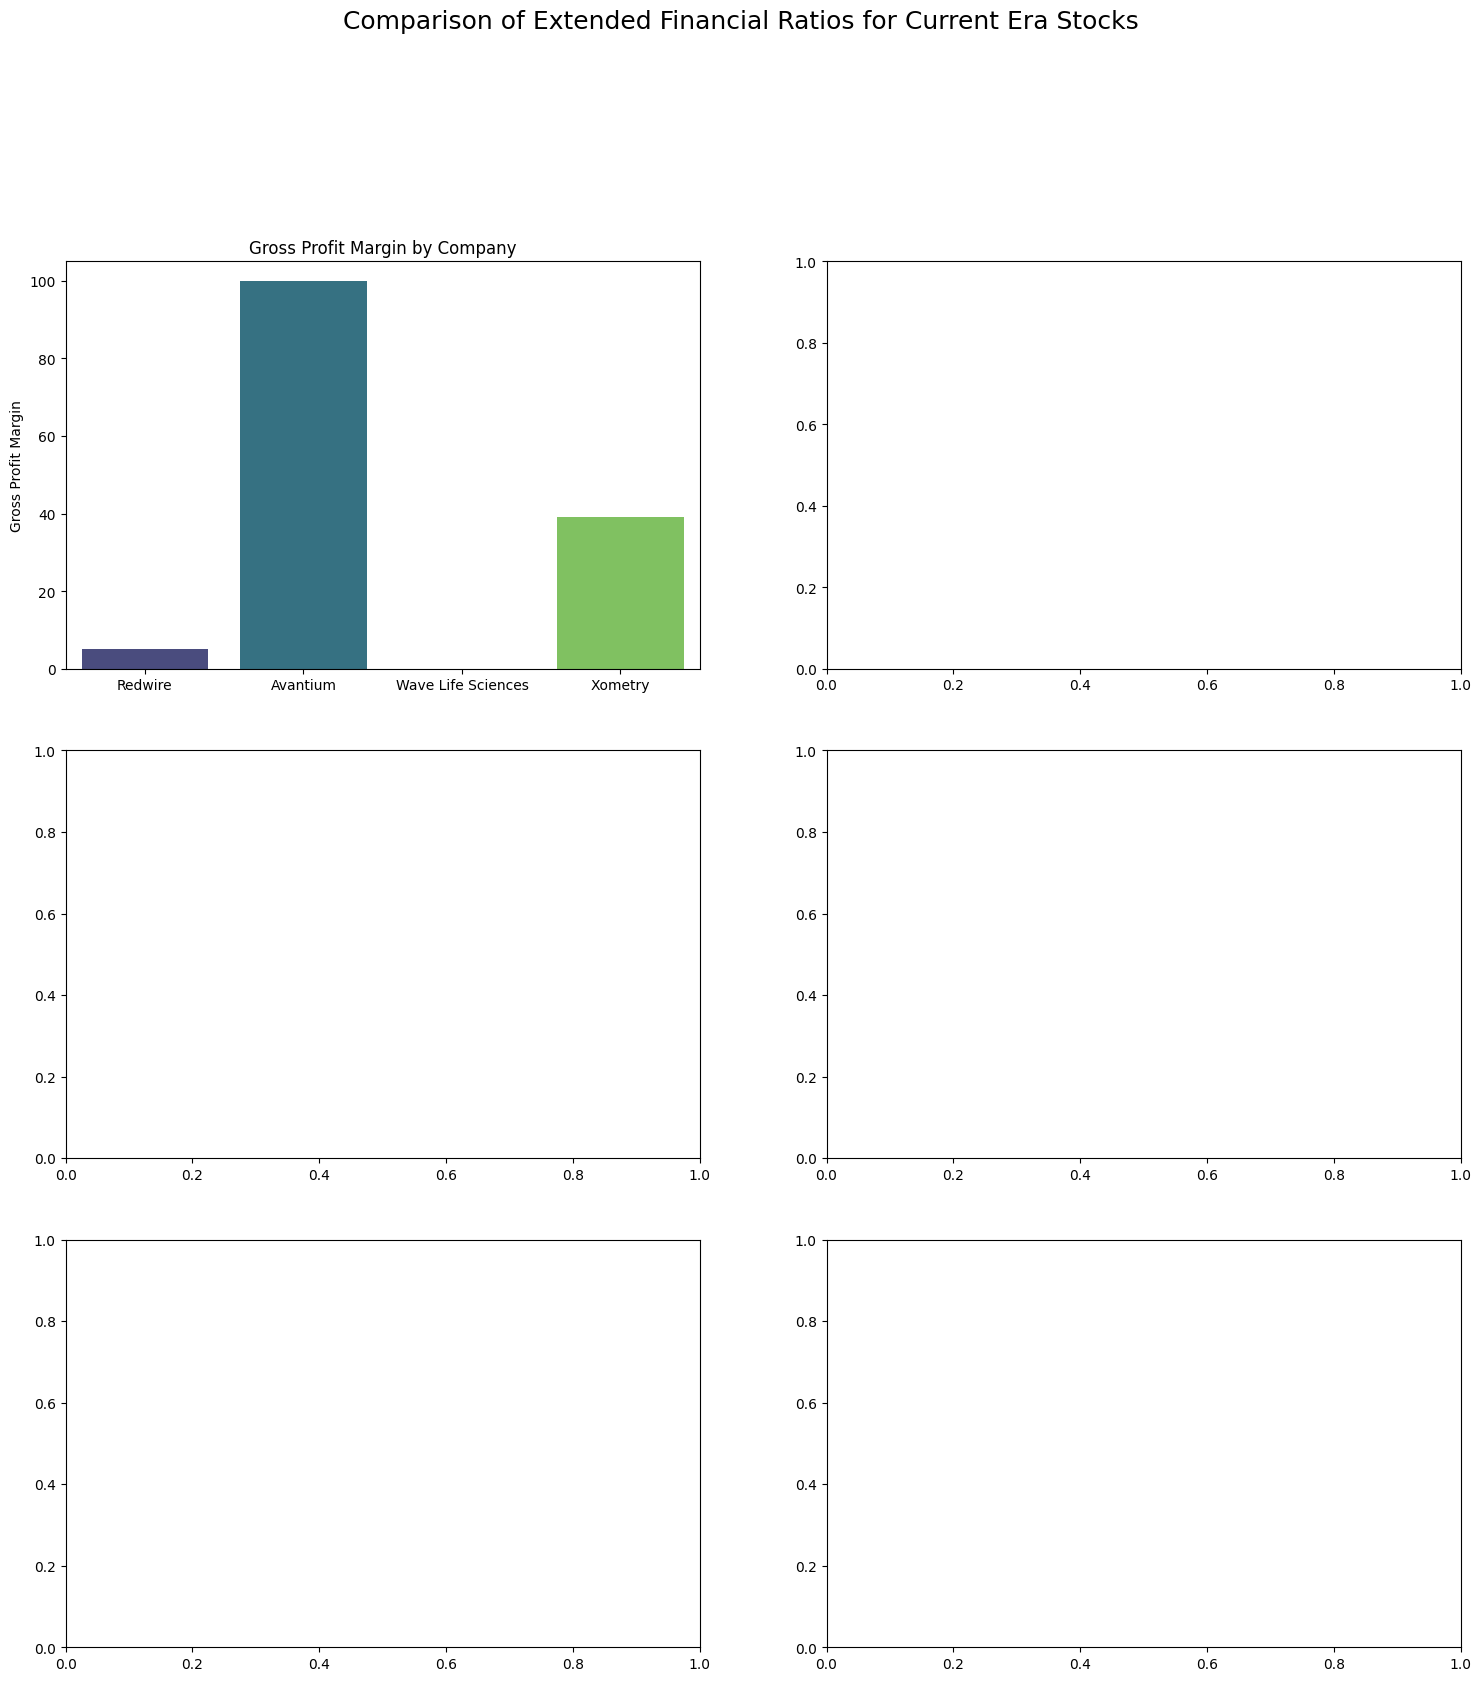

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the new ratios to plot
new_ratios_to_plot = [
    'Gross Profit Margin',
    'Operating Profit Margin',
    'Net Profit Margin',
    'Quick Ratio',
    'Interest Coverage Ratio',
    'Asset Turnover Ratio'
]

# Set up the matplotlib figure and axes for the new ratios (3 rows, 2 columns)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
axes = axes.flatten() # Flatten the array of axes for easy iteration

plt.suptitle('Comparison of Extended Financial Ratios for Current Era Stocks', fontsize=18, y=1.02)

for i, ratio in enumerate(new_ratios_to_plot):
    if ratio in calculated_ratios_extended_df.columns:
        sns.barplot(x=calculated_ratios_extended_df.index, y=ratio, data=calculated_ratios_extended_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{ratio} by Company')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    else:
        axes[i].set_visible(False) # Hide empty subplots if a ratio is missing

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# Install the twelvedata library to ensure it's available
!pip install twelvedata

from twelvedata import TDClient
import pandas as pd
from google.colab import userdata
import numpy as np

# Get the API key from Colab secrets
TWELVE_DATA_API_KEY = userdata.get('TWELVE_DATA_API_KEY')

# Initialize the client
tdc = TDClient(apikey=TWELVE_DATA_API_KEY)

# Tickers for Dot-Com era analysis
dot_com_era_tickers = {
    'Cisco': 'CSCO',
    'Intel': 'INTC',
    'Microsoft': 'MSFT',
    'Amazon': 'AMZN'
}

START_DATE = "1997-01-01"
END_DATE = "2003-12-31"

all_dot_com_de_data = []

print("\n--- Attempting to fetch historical quarterly balance sheets from Twelve Data for Dot-Com Era ---")

for company_name, ticker_symbol in dot_com_era_tickers.items():
    print(f"\nProcessing {company_name} ({ticker_symbol}) with Twelve Data...")
    try:
        # Attempt to get quarterly balance sheet data
        # Note: This endpoint often requires a paid plan.
        balance_sheet_data = tdc.balance_sheet(symbol=ticker_symbol, interval="quarterly").as_json()

        if balance_sheet_data and isinstance(balance_sheet_data, list):
            df_bs = pd.DataFrame(balance_sheet_data)
            if not df_bs.empty:
                df_bs['datetime'] = pd.to_datetime(df_bs['datetime'])
                df_bs = df_bs.set_index('datetime').sort_index()

                # Extract Total Debt and Equity (these keys might vary)
                total_debt = df_bs.get('total_debt', df_bs.get('TotalDebt', np.nan))
                total_equity = df_bs.get('total_equity', df_bs.get('TotalStockholderEquity', np.nan))

                if not (pd.isna(total_debt).all() or pd.isna(total_equity).all()):
                    debt_to_equity = (total_debt / total_equity).replace([np.inf, -np.inf], np.nan).dropna()
                    debt_to_equity = debt_to_equity.loc[(debt_to_equity.index >= START_DATE) & (debt_to_equity.index <= END_DATE)]

                    if not debt_to_equity.empty:
                        all_dot_com_de_data.append({'Company': company_name, 'D/E_Ratio': debt_to_equity})
                        print(f"  Successfully fetched D/E data for {company_name} from Twelve Data.")
                    else:
                        print(f"  No relevant D/E data found for {company_name} within the Dot-Com era from Twelve Data.")
                else:
                    print(f"  Could not find 'total_debt' or 'total_equity' in Twelve Data balance sheet for {company_name}.")
            else:
                print(f"  Balance sheet data for {company_name} from Twelve Data is empty.")
        elif balance_sheet_data and 'code' in balance_sheet_data and balance_sheet_data['code'] == 403:
            print(f"  Twelve Data API restriction: {balance_sheet_data['message']}")
            print(f"  Balance sheet data for {company_name} requires a paid plan. Cannot proceed with D/E ratio.")
        else:
            print(f"  No balance sheet data or unexpected response for {company_name} from Twelve Data.")

    except Exception as e:
        print(f"  Error fetching balance sheet for {company_name} ({ticker_symbol}) with Twelve Data: {e}")

if all_dot_com_de_data:
    print("\n--- Dot-Com Era Debt-to-Equity Ratios from Twelve Data (if available) ---")
    for item in all_dot_com_de_data:
        print(f"\nCompany: {item['Company']}")
        display(item['D/E_Ratio'])
else:
    print("\nNo Debt-to-Equity data for Dot-Com era tickers could be retrieved from Twelve Data due to API limitations or data unavailability.")

ModuleNotFoundError: No module named 'twelvedata'

### 3. Polygon.io

Polygon.io offers a free tier for delayed stock, options, forex, and crypto data. It's known for its comprehensive API.

To use Polygon.io:

1.  **Get an API Key:** Sign up on the [Polygon.io website](https://polygon.io/dashboard/signup) to obtain your free API key.
2.  **Store it securely:** Add your API key to Colab's Secrets Manager with the name `POLYGON_API_KEY`.
3.  **Install the library:** I'll provide code to install the `polygon-api-client` Python library.
4.  **Fetch data:** We'll fetch historical daily prices for a sample ticker (e.g., 'AAPL').


In [ ]:
# Install the Polygon API client library
!pip install polygon-api-client

In [ ]:
from polygon import RESTClient
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
POLYGON_API_KEY = userdata.get('POLYGON_API_KEY')

# Initialize the RESTClient
client = RESTClient(POLYGON_API_KEY)

ticker_symbol = 'AAPL'
start_date = '2023-01-01'
end_date = '2023-03-01'

print(f"\nAttempting to fetch historical daily prices for {ticker_symbol} from Polygon.io...")

try:
    # Fetch aggregates (daily bars) for the ticker
    # Note: Free tier is for delayed data and might have rate limits or specific date range restrictions.
    aggs = []
    for a in client.list_aggs(ticker=ticker_symbol,
                             multiplier=1,
                             timespan='day',
                             from_=start_date,
                             to=end_date,
                             limit=50000): # Increased limit to ensure more data if available
        aggs.append(a)

    if aggs:
        # Convert to DataFrame
        df = pd.DataFrame(aggs)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df = df.set_index('timestamp').sort_index()
        print(f"\nHistorical daily prices from Polygon.io for {ticker_symbol} (first 5 rows):")
        display(df.head())
    else:
        print(f"No historical data found for {ticker_symbol} via Polygon.io. Check API key, ticker, or date range.")

except Exception as e:
    print(f"Error fetching data from Polygon.io for {ticker_symbol}: {e}")
    print("Please ensure your Polygon.io API key is valid and correctly entered in Colab secrets as 'POLYGON_API_KEY'.")
    print("Remember the free tier has limitations (e.g., delayed data, rate limits).")

### 4. IEX Cloud (IEX Exchange API)

IEX Cloud offers market data, fundamental data, and news, with a developer-friendly API and a free tier with usage limits.

To use IEX Cloud:

1.  **Get an API Key:** Sign up on the [IEX Cloud Console](https://iexcloud.io/console/signup) to obtain your 'pk_' (publishable) API key.
2.  **Store it securely:** Add your API key to Colab's Secrets Manager with the name `IEX_CLOUD_API_KEY`.
3.  **Install the library:** I'll provide code to install the `iexfinance` Python library.
4.  **Fetch data:** We'll fetch historical prices for a sample ticker (e.g., 'AAPL').


In [ ]:
# Install the iexfinance library
!pip install iexfinance

In [ ]:
from iexfinance.stocks import get_historical_data
from iexfinance.stocks import Stock
from datetime import datetime
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
IEX_CLOUD_API_KEY = userdata.get('IEX_CLOUD_API_KEY')

ticker_symbol = 'AAPL'
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 3, 1)

print(f"\nAttempting to fetch historical daily prices for {ticker_symbol} from IEX Cloud...")

try:
    # Fetch historical data
    df = get_historical_data(ticker_symbol, start=start_date, end=end_date, output_format='pandas', token=IEX_CLOUD_API_KEY)

    if not df.empty:
        print(f"\nHistorical daily prices from IEX Cloud for {ticker_symbol} (first 5 rows):")
        display(df.head())
    else:
        print(f"No historical data found for {ticker_symbol} via IEX Cloud. Check API key, ticker, or date range. Remember free tier limits.")

except Exception as e:
    print(f"Error fetching data from IEX Cloud for {ticker_symbol}: {e}")
    print("Please ensure your IEX Cloud API key (starting with 'pk_') is valid and correctly entered in Colab secrets as 'IEX_CLOUD_API_KEY'.")
    print("Also, verify your free tier usage limits haven't been exceeded.")

### 5. Twelve Data

Twelve Data provides real-time and historical market data, including stocks, forex, crypto, and indices. They offer a free API plan with limited requests.

To use Twelve Data:

1.  **Get an API Key:** Sign up on the [Twelve Data website](https://twelvedata.com/pricing) for the 'Free API' plan.
2.  **Store it securely:** Add your API key to Colab's Secrets Manager with the name `TWELVE_DATA_API_KEY`.
3.  **Install the library:** I'll provide code to install the `twelvedata` Python library.
4.  **Fetch data:** We'll fetch historical daily prices for a sample ticker (e.g., 'AAPL').


In [ ]:
# Install the twelvedata library
!pip install twelvedata

In [ ]:
# Install the twelvedata library
!pip install twelvedata

from twelvedata import TDClient
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
TWELVE_DATA_API_KEY = userdata.get('TWELVE_DATA_API_KEY')

# Initialize the client
tdc = TDClient(apikey=TWELVE_DATA_API_KEY)

ticker_symbol = 'AAPL'

print(f"\nAttempting to fetch historical daily prices for {ticker_symbol} from Twelve Data...")

try:
    # Fetch historical time series data
    # Free plan usually allows only up to 30 days of historical data and 8 requests per minute.
    ts = tdc.time_series(symbol=ticker_symbol, interval="1day", outputsize=30).as_pandas()

    if not ts.empty:
        print(f"\nHistorical daily prices from Twelve Data for {ticker_symbol} (first 5 rows):")
        display(ts.head())
    else:
        print(f"No historical data found for {ticker_symbol} via Twelve Data. Check API key, ticker, or limits.")

except Exception as e:
    print(f"Error fetching data from Twelve Data for {ticker_symbol}: {e}")
    print("Please ensure your Twelve Data API key is valid and correctly entered in Colab secrets as 'TWELVE_DATA_API_KEY'.")
    print("Remember the free plan has strict limits on historical data depth and request frequency.")

### 6. Tiingo

Tiingo offers financial data APIs for historical data, end-of-day, and real-time. They provide a free tier with daily updates for end-of-day data.

To use Tiingo:

1.  **Get an API Key:** Sign up on the [Tiingo website](https://api.tiingo.com/) for a free account.
2.  **Store it securely:** Add your API key to Colab's Secrets Manager with the name `TIINGO_API_KEY`.
3.  **Install the library:** I'll provide code to install the `tiingo` Python library.
4.  **Fetch data:** We'll fetch historical daily prices for a sample ticker (e.g., 'AAPL').


In [ ]:
# Install the tiingo library
!pip install tiingo

In [ ]:
from tiingo import TiingoClient
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
TIINGO_API_KEY = userdata.get('TIINGO_API_KEY')

# Initialize the client
config = {
    'session': True, # Use persistent session
    'api_key': TIINGO_API_KEY
}
client = TiingoClient(config)

ticker_symbol = 'AAPL'
start_date = '2023-01-01'
end_date = '2023-03-01'

print(f"\nAttempting to fetch historical daily prices for {ticker_symbol} from Tiingo...")

try:
    # Fetch historical daily prices
    # Free tier usually has limits on historical data and request frequency.
    historical_prices = client.get_dataframe(
        ticker_symbol,
        frequency='daily',
        startDate=start_date,
        endDate=end_date
    )

    if not historical_prices.empty:
        print(f"\nHistorical daily prices from Tiingo for {ticker_symbol} (first 5 rows):")
        display(historical_prices.head())
    else:
        print(f"No historical data found for {ticker_symbol} via Tiingo. Check API key, ticker, or date range.")

except Exception as e:
    print(f"Error fetching data from Tiingo for {ticker_symbol}: {e}")
    print("Please ensure your Tiingo API key is valid and correctly entered in Colab secrets as 'TIINGO_API_KEY'.")
    print("Remember the free tier has limitations.")


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Tickers for Dot-Com era analysis
dot_com_era_tickers = {
    'Cisco': 'CSCO',
    'Intel': 'INTC',
    'Microsoft': 'MSFT',
    'Amazon': 'AMZN'
}

# Define the specific period for Dot-Com analysis (e.g., 1997 to 2003)
START_DATE = "1997-01-01"
END_DATE = "2003-12-31"

plt.figure(figsize=(18, 15))
plt.suptitle('Dot-Com Era: Stock Price vs. Debt-to-Equity Ratio (1997-2003)', y=1.02, fontsize=16)

plot_idx = 1
for company_name, ticker_symbol in dot_com_era_tickers.items():
    print(f"\nProcessing {company_name} ({ticker_symbol})...")
    try:
        # 1. Fetch historical daily prices
        price_data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")
        if price_data.empty:
            print(f"No price data found for {company_name}. Skipping.")
            continue

        price_series = price_data['Adj Close'].squeeze()
        if price_series.empty:
            price_series = price_data['Close'].squeeze() # Fallback if Adj Close is not available
        if price_series.empty:
            print(f"No valid price series found for {company_name}. Skipping.")
            continue

        # 2. Fetch quarterly balance sheets to calculate Debt-to-Equity
        ticker = yf.Ticker(ticker_symbol)
        balance_sheet_quarterly = ticker.quarterly_balance_sheet

        # Check if balance sheet data is available and has required fields
        if balance_sheet_quarterly.empty:
            print(f"No quarterly balance sheet data found for {company_name}. Skipping.")
            continue

        # Transpose to have dates as index
        balance_sheet_quarterly = balance_sheet_quarterly.T

        # Find relevant debt and equity keys (checking for common variations)
        total_debt_keys = ['Total Debt', 'Long Term Debt And Capital Lease Obligation', 'Long Term Debt', 'Current Debt And Capital Lease Obligation']
        equity_keys = ['Stockholders Equity', 'Total Equity Gross Minority Interest', 'Share Holder Equity']

        total_debt = pd.Series(dtype=float)
        for key in total_debt_keys:
            if key in balance_sheet_quarterly.columns:
                total_debt = balance_sheet_quarterly[key]
                break
        if total_debt.empty:
             # Attempt to sum common debt components if 'Total Debt' not found directly
            current_debt = balance_sheet_quarterly.get('Current Debt And Capital Lease Obligation', 0)
            long_term_debt = balance_sheet_quarterly.get('Long Term Debt And Capital Lease Obligation', 0)
            if isinstance(current_debt, pd.Series) and isinstance(long_term_debt, pd.Series):
                total_debt = current_debt.fillna(0) + long_term_debt.fillna(0)
            elif isinstance(current_debt, pd.Series): total_debt = current_debt
            elif isinstance(long_term_debt, pd.Series): total_debt = long_term_debt

        shareholder_equity = pd.Series(dtype=float)
        for key in equity_keys:
            if key in balance_sheet_quarterly.columns:
                shareholder_equity = balance_sheet_quarterly[key]
                break

        if total_debt.empty or shareholder_equity.empty:
            print(f"Could not find sufficient debt or equity data for {company_name}. Skipping.")
            continue

        # Filter D/E data to the specified period
        total_debt = total_debt.loc[total_debt.index.intersection(pd.to_datetime(pd.date_range(START_DATE, END_DATE)))]
        shareholder_equity = shareholder_equity.loc[shareholder_equity.index.intersection(pd.to_datetime(pd.date_range(START_DATE, END_DATE)))]

        # Calculate Debt-to-Equity ratio
        debt_to_equity = total_debt / shareholder_equity
        debt_to_equity = debt_to_equity.replace([np.inf, -np.inf], np.nan).dropna()

        if debt_to_equity.empty:
            print(f"Calculated Debt-to-Equity is empty for {company_name}. Skipping.")
            continue

        # 3. Align D/E (quarterly) with daily prices
        # Create a daily date range within the analysis period
        full_date_range = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
        aligned_de = pd.Series(index=full_date_range, dtype=float)

        # Forward-fill quarterly D/E values to daily dates
        for q_date in sorted(debt_to_equity.index):
            # Find all daily dates from this quarter-end until the next quarter-end or end of period
            if q_date <= pd.to_datetime(END_DATE):
                start_fill_date = q_date
                next_q_dates = [d for d in debt_to_equity.index if d > q_date]
                end_fill_date = next_q_dates[0] if next_q_dates else pd.to_datetime(END_DATE)

                # Ensure end_fill_date is within the overall range and after start_fill_date
                end_fill_date = min(end_fill_date, pd.to_datetime(END_DATE))

                daily_dates_to_fill = pd.date_range(start=start_fill_date, end=end_fill_date, freq='D')
                # Make sure the dates are valid for the index
                daily_dates_to_fill = daily_dates_to_fill[daily_dates_to_fill.isin(aligned_de.index)]

                if not daily_dates_to_fill.empty:
                    aligned_de.loc[daily_dates_to_fill] = debt_to_equity.loc[q_date]

        # Fill any remaining NaNs at the beginning with the first available value
        aligned_de = aligned_de.ffill().loc[price_series.index] # Align to price_series index after ffill

        # 4. Plotting
        ax1 = plt.subplot(2, 2, plot_idx) # Price on left y-axis
        color = 'tab:blue'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Stock Price', color=color)
        ax1.plot(price_series.index, price_series, color=color, label='Stock Price')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.set_title(f'{company_name} ({ticker_symbol})')
        ax1.grid(True)
        ax1.tick_params(axis='x', rotation=45)

        ax2 = ax1.twinx() # Debt-to-Equity on right y-axis
        color = 'tab:red'
        ax2.set_ylabel('Debt-to-Equity Ratio', color=color)
        ax2.plot(aligned_de.index, aligned_de, color=color, linestyle='--', label='Debt-to-Equity Ratio')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_ylim(bottom=0) # Ensure D/E starts from 0 for better visualization

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        plot_idx += 1

    except Exception as e:
        print(f"Error processing {company_name} ({ticker_symbol}): {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### Comparison of Bubble Indicators for Dot-Com Era Stocks

To analyze the 'Bubble Indicator' for the Dot-Com era, we will use a selection of prominent stocks from that period and examine their performance around the time of the bubble (e.g., 1997-2003). Plotting these on a single graph will allow us to observe common trends, individual stock volatility, and the manifestation of 'bubble' characteristics during that historical period.

The 'Bubble Indicator' is calculated as: $$\text{Bubble Indicator} = \frac{\text{Close Price} - \text{50-day SMA}}{\text{20-day SMA}}$$

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Tickers for Dot-Com era analysis
dot_com_era_tickers = {
    'Cisco': 'CSCO',
    'Intel': 'INTC',
    'Microsoft': 'MSFT',
    'Amazon': 'AMZN'
}

# Define SMA periods for the Bubble Indicator
SMA_SHORT = 20
SMA_LONG = 50

bubble_indicators_dot_com_df = pd.DataFrame()

# Define the specific period for Dot-Com analysis (e.g., 1997 to 2003)
START_DATE = "1997-01-01"
END_DATE = "2003-12-31"

print(f"Fetching data for Dot-Com era stocks from {START_DATE} to {END_DATE}...")

for company_name, ticker_symbol in dot_com_era_tickers.items():
    try:
        # Fetch historical data for the specified Dot-Com period
        data = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, interval="1d")

        if data.empty:
            print(f"No historical data found for {company_name} ({ticker_symbol}) in the specified Dot-Com era. Skipping comparison for this stock.")
            continue

        # Determine the correct price series to use for calculations
        price_series = None
        if 'Adj Close' in data.columns:
            price_series = data['Adj Close'].squeeze()
        elif 'Close' in data.columns:
            price_series = data['Close'].squeeze()

        if price_series is None or not isinstance(price_series, pd.Series):
            print(f"Error: Could not extract a single price series for {company_name} ({ticker_symbol}). Skipping comparison.")
            continue

        # Calculate SMAs using the selected price_series
        data[f'SMA_{SMA_SHORT}'] = price_series.rolling(window=SMA_SHORT).mean()
        data[f'SMA_{SMA_LONG}'] = price_series.rolling(window=SMA_LONG).mean()

        # Calculate Bubble Indicator
        data['Bubble_Indicator'] = (price_series - data[f'SMA_{SMA_LONG}']) / data[f'SMA_{SMA_SHORT}']

        # Add to the comparison DataFrame
        bubble_indicators_dot_com_df[company_name] = data['Bubble_Indicator']

    except Exception as e:
        print(f"Error processing {company_name} ({ticker_symbol}) for comparison: {e}")

# Plotting the combined Bubble Indicators for Dot-Com era stocks
if not bubble_indicators_dot_com_df.empty:
    plt.figure(figsize=(15, 8))
    for column in bubble_indicators_dot_com_df.columns:
        plt.plot(bubble_indicators_dot_com_df.index, bubble_indicators_dot_com_df[column], label=f'{column} Bubble Indicator', alpha=0.8)

    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title('Comparison of Bubble Indicators for Dot-Com Era Stocks')
    plt.xlabel('Date')
    plt.ylabel('Bubble Indicator Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No Bubble Indicator data available for Dot-Com era comparison.")

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Tickers for current era analysis
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

# Define SMA periods for the Bubble Indicator
SMA_SHORT = 20
SMA_LONG = 50

bubble_indicators_df = pd.DataFrame()

for company_name, ticker_symbol in current_era_tickers.items():
    try:
        # Fetch historical data for a sufficiently long period (e.g., 2 years)
        data = yf.download(ticker_symbol, period="2y", interval="1d")

        if data.empty:
            print(f"No historical data found for {company_name} ({ticker_symbol}). Skipping comparison for this stock.")
            continue

        # Determine the correct price series to use for calculations
        price_series = None
        if 'Adj Close' in data.columns:
            price_series = data['Adj Close'].squeeze()
        elif 'Close' in data.columns:
            price_series = data['Close'].squeeze()

        if price_series is None or not isinstance(price_series, pd.Series):
            print(f"Error: Could not extract a single price series for {company_name} ({ticker_symbol}). Skipping comparison.")
            continue

        # Calculate SMAs using the selected price_series
        data[f'SMA_{SMA_SHORT}'] = price_series.rolling(window=SMA_SHORT).mean()
        data[f'SMA_{SMA_LONG}'] = price_series.rolling(window=SMA_LONG).mean()

        # Calculate Bubble Indicator
        data['Bubble_Indicator'] = (price_series - data[f'SMA_{SMA_LONG}']) / data[f'SMA_{SMA_SHORT}']

        # Add to the comparison DataFrame
        bubble_indicators_df[company_name] = data['Bubble_Indicator']

    except Exception as e:
        print(f"Error processing {company_name} ({ticker_symbol}) for comparison: {e}")

# Plotting the combined Bubble Indicators
if not bubble_indicators_df.empty:
    plt.figure(figsize=(15, 8))
    for column in bubble_indicators_df.columns:
        plt.plot(bubble_indicators_df.index, bubble_indicators_df[column], label=f'{column} Bubble Indicator', alpha=0.8)

    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title('Comparison of Bubble Indicators for Current Era Stocks')
    plt.xlabel('Date')
    plt.ylabel('Indicator Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No Bubble Indicator data available for comparison.")

### Price Trends and Bubble Indicator for Current Era Stocks

To analyze potential bubble characteristics, we will:
1.  **Fetch historical price data** for the current era stocks (Redwire, Avantium, Wave Life Sciences, Xometry).
2.  **Calculate Simple Moving Averages (SMAs):** Specifically, 20-day and 50-day SMAs.
3.  **Calculate the 'Bubble Indicator':**
    $$\text{Bubble Indicator} = \frac{\text{Close Price} - \text{50-day SMA}}{\text{20-day SMA}}$$
    This indicator quantifies how much the current price has diverged from its longer-term trend (50-day SMA), relative to its short-term volatility/momentum (20-day SMA).
4.  **Plot the price trends, SMAs, and the Bubble Indicator** for each stock.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tickers for current era analysis (excluding Velo3D due to data limitations)
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

# Define SMA periods for the Bubble Indicator
SMA_SHORT = 20
SMA_LONG = 50

plt.figure(figsize=(18, 12))

for i, (company_name, ticker_symbol) in enumerate(current_era_tickers.items()):
    try:
        # Fetch historical data for a sufficiently long period (e.g., 2 years)
        data = yf.download(ticker_symbol, period="2y", interval="1d")

        if data.empty:
            print(f"No historical data found for {company_name} ({ticker_symbol}).")
            continue

        # Determine the correct price series to use for calculations
        # Prioritize 'Adj Close' as it's the most accurate for historical analysis,
        # otherwise use 'Close'. Explicitly use .squeeze() to ensure it's a Series.
        price_series = None
        if 'Adj Close' in data.columns:
            price_series = data['Adj Close'].squeeze()
        elif 'Close' in data.columns:
            price_series = data['Close'].squeeze()
        else:
            print(f"Error: Neither 'Adj Close' nor 'Close' column found for {company_name} ({ticker_symbol}). Skipping.")
            continue

        # If price_series is not a Series (e.g., if squeeze() failed because it was already a multi-column DataFrame)
        if not isinstance(price_series, pd.Series):
            print(f"Error: Could not extract a single price series for {company_name} ({ticker_symbol}). Skipping.")
            continue

        # Calculate SMAs using the selected price_series
        data[f'SMA_{SMA_SHORT}'] = price_series.rolling(window=SMA_SHORT).mean()
        data[f'SMA_{SMA_LONG}'] = price_series.rolling(window=SMA_LONG).mean()

        # Calculate Bubble Indicator
        # Ensure we don't divide by zero or NaN for SMA_SHORT
        data['Bubble_Indicator'] = (price_series - data[f'SMA_{SMA_LONG}']) / data[f'SMA_{SMA_SHORT}']

        # Plotting
        plt.subplot(len(current_era_tickers), 2, 2*i + 1) # Price and SMAs
        plt.plot(price_series, label='Close Price', alpha=0.7) # Use price_series here
        plt.plot(data[f'SMA_{SMA_SHORT}'], label=f'{SMA_SHORT}-day SMA', alpha=0.7)
        plt.plot(data[f'SMA_{SMA_LONG}'], label=f'{SMA_LONG}-day SMA', alpha=0.7)
        plt.title(f'{company_name} ({ticker_symbol}) Price Trend & SMAs')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)

        plt.subplot(len(current_era_tickers), 2, 2*i + 2) # Bubble Indicator
        plt.plot(data['Bubble_Indicator'], label='Bubble Indicator', color='red', alpha=0.7)
        plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        plt.title(f'{company_name} ({ticker_symbol}) Bubble Indicator')
        plt.xlabel('Date')
        plt.ylabel('Indicator Value')
        plt.legend()
        plt.grid(True)

    except Exception as e:
        print(f"Error processing {company_name} ({ticker_symbol}): {e}")

plt.tight_layout()
plt.suptitle('Price Trends, SMAs, and Bubble Indicator for Current Era Stocks', y=1.02, fontsize=16)
plt.show()

Certainly! Here's a comprehensive explanation of the mathematical expressions and conceptual framework for each financial metric we've discussed. I will break them down by category, providing the formula and defining its components.

### I. Profitability Ratios
These ratios measure a company's ability to generate earnings relative to its revenue, assets, or equity.

**Net Interest Margin (NIM)**

*   **Formula:** $$\text{NIM} = \frac{\text{Interest Income} - \text{Interest Expense}}{\text{Average Earning Assets}}$$
*   **Components:**
    *   **Interest Income:** Revenue generated from interest-bearing assets (e.g., loans, investments).
    *   **Interest Expense:** Cost incurred from interest-bearing liabilities (e.g., deposits, borrowed funds).
    *   **Average Earning Assets:** The average value of assets that generate interest income (e.g., average loans, average investment securities).
*   **Concept:** This is primarily a banking metric. It indicates how successfully a bank is investing its funds (loans, investments) compared to the cost of funding those investments.

**Return on Assets (ROA)**

*   **Formula:** $$\text{ROA} = \frac{\text{Net Income}}{\text{Total Assets}}$$
*   **Components:**
    *   **Net Income:** The company's total earnings after all expenses, including taxes and interest, have been deducted.
    *   **Total Assets:** The sum of all assets owned by the company (e.g., cash, inventory, property, plant, equipment).
*   **Concept:** Measures how efficiently a company is using its assets to generate profit. A higher ROA generally means more asset efficiency.

**Return on Equity (ROE)**

*   **Formula:** $$\text{ROE} = \frac{\text{Net Income}}{\text{Shareholder Equity}}$$
*   **Components:**
    *   **Net Income:** As defined above.
    *   **Shareholder Equity:** The total amount of capital invested by shareholders, plus retained earnings.
*   **Concept:** Measures the rate of return on the ownership interest of the common stockholders. It indicates how much profit a company generates for each dollar of equity.

**Earnings Per Share (EPS)**

*   **Formula:** $$\text{EPS} = \frac{\text{Net Income} - \text{Preferred Dividends}}{\text{Average Outstanding Shares}}$$
*   **Components:**
    *   **Net Income:** As defined above.
    *   **Preferred Dividends:** Dividends paid to holders of preferred stock, which are subtracted as they are not available to common shareholders.
    *   **Average Outstanding Shares:** The average number of common shares held by investors during the period.
*   **Concept:** Represents the portion of a company's profit allocated to each outstanding share of common stock. It's a key indicator of profitability for individual shares.

**Gross Profit Margin**

*   **Formula:** $$\text{Gross Profit Margin} = \frac{\text{Revenue} - \text{Cost of Goods Sold}}{\text{Revenue}} \times 100\%$$$
*   **Components:**
    *   **Revenue (or Sales):** The total amount of money generated from the sale of goods or services.
    *   **Cost of Goods Sold (COGS):** The direct costs attributable to the production of the goods sold by a company.
*   **Concept:** Indicates the percentage of revenue remaining after subtracting the direct costs of producing goods or services. It shows the company's ability to control production costs.

**Operating Profit Margin**

*   **Formula:** $$\text{Operating Profit Margin} = \frac{\text{Operating Income}}{\text{Revenue}} \times 100\%$$$
*   **Components:**
    *   **Operating Income (or EBIT - Earnings Before Interest and Taxes):** Gross profit minus operating expenses (e.g., selling, general, and administrative expenses).
    *   **Revenue:** As defined above.
*   **Concept:** Measures the percentage of revenue that is left after covering all operating expenses. It reflects the efficiency of a company's core operations.

**Net Profit Margin**

*   **Formula:** $$\text{Net Profit Margin} = \frac{\text{Net Income}}{\text{Revenue}} \times 100\%$$$
*   **Components:**
    *   **Net Income:** As defined above.
    *   **Revenue:** As defined above.
*   **Concept:** Shows the percentage of revenue that translates into net income. It's a comprehensive measure of profitability, taking all costs and taxes into account.

### II. Liquidity Ratios
These ratios assess a company's ability to meet its short-term obligations.

**Current Ratio**

*   **Formula:** $$\text{Current Ratio} = \frac{\text{Current Assets}}{\text{Current Liabilities}}$$
*   **Components:**
    *   **Current Assets:** Assets that can be converted into cash within one year (e.g., cash, accounts receivable, inventory).
    *   **Current Liabilities:** Obligations due within one year (e.g., accounts payable, short-term debt).
*   **Concept:** Indicates a company's ability to pay off its short-term debts with its short-term assets. A ratio greater than 1 is generally preferred.

**Quick Ratio (Acid-Test Ratio)**

*   **Formula:** $$\text{Quick Ratio} = \frac{\text{Current Assets} - \text{Inventory}}{\text{Current Liabilities}}$$
*   **Components:**
    *   **Current Assets, Inventory, Current Liabilities:** As defined above.
*   **Concept:** A more conservative measure of liquidity than the current ratio, as it excludes inventory (which can be difficult to quickly convert to cash) from current assets.

**Cash Ratio**

*   **Formula:** $$\text{Cash Ratio} = \frac{\text{Cash & Cash Equivalents}}{\text{Current Liabilities}}$$
*   **Components:**
    *   **Cash & Cash Equivalents:** The most liquid assets a company holds (e.g., cash, short-term marketable securities).
    *   **Current Liabilities:** As defined above.
*   **Concept:** The most stringent liquidity ratio, measuring a company's ability to pay off its current liabilities using only its cash and cash equivalents.

### III. Solvency Ratios
These ratios evaluate a company's ability to meet its long-term debt obligations.

**Debt-to-Equity Ratio**

*   **Formula:** $$\text{Debt-to-Equity Ratio} = \frac{\text{Total Debt}}{\text{Shareholder Equity}}$$
*   **Components:**
    *   **Total Debt:** Includes both short-term and long-term liabilities.
    *   **Shareholder Equity:** As defined above.
*   **Concept:** Measures the proportion of a company's assets financed by debt versus equity. A higher ratio indicates higher financial leverage and risk.

**Debt-to-Asset Ratio**

*   **Formula:** $$\text{Debt-to-Asset Ratio} = \frac{\text{Total Debt}}{\text{Total Assets}}$$
*   **Components:**
    *   **Total Debt:** As defined above.
    *   **Total Assets:** As defined above.
*   **Concept:** Indicates the percentage of a company's assets that are financed by creditors. A higher ratio means more assets are funded by debt.

**Interest Coverage Ratio**

*   **Formula:** $$\text{Interest Coverage Ratio} = \frac{\text{EBIT}}{\text{Interest Expense}}$$
*   **Components:**
    *   **EBIT (Earnings Before Interest and Taxes):** Operating income, as defined above.
    *   **Interest Expense:** The cost a company incurs for borrowed funds.
*   **Concept:** Measures a company's ability to meet its interest obligations. A higher ratio suggests that the company can more easily pay its interest expenses.

### IV. Efficiency Ratios
These ratios evaluate how efficiently a company uses its assets and manages its liabilities.

**Asset Turnover Ratio**

*   **Formula:** $$\text{Asset Turnover Ratio} = \frac{\text{Revenue}}{\text{Total Assets}}$$
*   **Components:**
    *   **Revenue:** As defined above.
    *   **Total Assets:** As defined above.
*   **Concept:** Measures how effectively a company is using its assets to generate sales. A higher ratio indicates better asset utilization.

**Inventory Turnover**

*   **Formula:** $$\text{Inventory Turnover} = \frac{\text{Cost of Goods Sold}}{\text{Average Inventory}}$$
*   **Components:**
    *   **Cost of Goods Sold (COGS):** As defined above.
    *   **Average Inventory:** The average value of inventory over a period (e.g., (Beginning Inventory + Ending Inventory) / 2).
*   **Concept:** Measures how many times a company has sold and replaced its inventory during a period. A higher turnover generally indicates efficient inventory management.

**Days Sales Outstanding (DSO)**

*   **Formula:** $$\text{DSO} = \frac{\text{Accounts Receivable}}{\text{Total Sales}} \times \text{Number of Days in Period}}$$
*   **Components:**
    *   **Accounts Receivable:** Money owed to the company by customers for goods or services delivered on credit.
    *   **Total Sales:** The total credit sales over the period.
    *   **Number of Days in Period:** Typically 365 for a year or 90 for a quarter.
*   **Concept:** Measures the average number of days it takes for a company to collect its accounts receivable. A lower DSO is generally better, indicating quicker cash collection.

### V. Valuation Ratios
These ratios are used to determine the financial attractiveness of an investment.

**Price-to-Earnings (P/E) Ratio**

*   **Formula:** $$\text{P/E Ratio} = \frac{\text{Share Price}}{\text{Earnings Per Share (EPS)}}$$
*   **Components:**
    *   **Share Price:** The current market price of one share of the company's stock.
    *   **Earnings Per Share (EPS):** As defined above.
*   **Concept:** Compares a company's current share price to its per-share earnings. It indicates how much investors are willing to pay for each dollar of earnings. A high P/E can suggest growth expectations.

**Price-to-Book (P/B) Ratio**

*   **Formula:** $$\text{P/B Ratio} = \frac{\text{Share Price}}{\text{Book Value Per Share}}$$
*   **Components:**
    *   **Share Price:** As defined above.
    *   **Book Value Per Share:** (Shareholder Equity - Preferred Equity) / Total Outstanding Shares. Represents the value of equity if all assets were sold and liabilities paid.
*   **Concept:** Compares a company's market value to its book value. It indicates how investors value the company relative to its accounting value of equity.

**Dividend Yield**

*   **Formula:** $$\text{Dividend Yield} = \frac{\text{Annual Dividends Per Share}}{\text{Share Price}} \times 100\%$$$
*   **Components:**
    *   **Annual Dividends Per Share:** The total dividends paid out per share over a year.
    *   **Share Price:** As defined above.
*   **Concept:** Shows the percentage return an investor receives in dividends relative to the stock's current price. It's a measure of dividend income.

**Market Capitalization**

*   **Formula:** $$\text{Market Capitalization} = \text{Share Price} \times \text{Number of Outstanding Shares}$$
*   **Components:**
    *   **Share Price:** As defined above.
    *   **Number of Outstanding Shares:** The total number of a company's shares currently held by all its shareholders.
*   **Concept:** Represents the total dollar market value of a company's outstanding shares. It's often used to classify company size (small-cap, mid-cap, large-cap).

### VI. Banking Specific Metrics
These ratios are particularly relevant for analyzing the financial health and performance of banks.

**Loan-to-Deposit Ratio**

*   **Formula:** $$\text{Loan-to-Deposit Ratio} = \frac{\text{Total Loans}}{\text{Total Deposits}}$$
*   **Components:**
    *   **Total Loans:** The total value of all loans issued by the bank.
    *   **Total Deposits:** The total value of all customer deposits held by the bank.
*   **Concept:** Measures a bank's liquidity and how much of its depositor's money it has loaned out. A high ratio might indicate less liquidity.

**Tier 1 Capital Ratio**

*   **Formula:** $$\text{Tier 1 Capital Ratio} = \frac{\text{Tier 1 Capital}}{\text{Risk-Weighted Assets}}$$
*   **Components:**
    *   **Tier 1 Capital:** Core capital of a bank, including common equity and disclosed reserves, which is a measure of a bank's financial strength.
    *   **Risk-Weighted Assets (RWA):** A bank's assets weighted by their credit risk. For example, cash has zero risk weight, while a loan might have a higher risk weight.
*   **Concept:** A key measure of a bank's financial strength and its ability to absorb potential losses. Higher ratios indicate a stronger capital base.

**Cost-to-Income Ratio**

*   **Formula:** $$\text{Cost-to-Income Ratio} = \frac{\text{Operating Expenses}}{\text{Operating Income}}$$
*   **Components:**
    *   **Operating Expenses:** All non-interest expenses incurred by the bank (e.g., salaries, rent, technology costs).
    *   **Operating Income:** Income from core banking operations before taxes.
*   **Concept:** Measures a bank's operational efficiency. A lower ratio indicates that the bank is more efficient in managing its costs relative to its income.

**Non-Performing Loan (NPL) Ratio**

*   **Formula:** $$\text{NPL Ratio} = \frac{\text{Non-Performing Loans}}{\text{Total Loans}}$$
*   **Components:**
    *   **Non-Performing Loans:** Loans where the borrower has failed to make scheduled payments for a specified period (typically 90 days).
    *   **Total Loans:** The total value of all loans issued by the bank.
*   **Concept:** Indicates the quality of a bank's loan portfolio. A higher NPL ratio suggests a greater risk of loan defaults and potential financial instability for the bank.

This comprehensive breakdown covers the mathematical foundation and conceptual significance of each metric. Please let me know if you have any further questions on specific metrics or require more detail on their application!

In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

# Dictionary to store financial info for each ticker
financial_data = {}

for company_name, ticker_symbol in tickers.items():
    print(f"\nFetching data for {company_name} ({ticker_symbol})...")
    try:
        ticker = yf.Ticker(ticker_symbol)
        # Get basic info, which often contains market cap, sector, industry, etc.
        info = ticker.info

        # Filter for relevant information that might indicate risk or key characteristics
        # This is a starting point; we can expand this based on what 'high risk' implies.
        relevant_info = {
            'symbol': info.get('symbol'),
            'longName': info.get('longName'),
            'sector': info.get('sector'),
            'industry': info.get('industry'),
            'marketCap': info.get('marketCap'),
            'beta': info.get('beta'), # Beta indicates volatility relative to the market
            'trailingPE': info.get('trailingPE'),
            'forwardPE': info.get('forwardPE'),
            'debtToEquity': info.get('debtToEquity'),
            'profitMargins': info.get('profitMargins'),
            'fullTimeEmployees': info.get('fullTimeEmployees'),
            'shortRatio': info.get('shortRatio'), # High short ratio can indicate high risk/bearish sentiment
            'totalCash': info.get('totalCash'),
            'totalDebt': info.get('totalDebt'),
            'country': info.get('country')
        }
        financial_data[company_name] = relevant_info
        print(f"Successfully fetched data for {company_name}.")
    except Exception as e:
        print(f"Error fetching data for {company_name} ({ticker_symbol}): {e}")

# Convert the dictionary of financial data to a DataFrame for better display
df_financial_data = pd.DataFrame.from_dict(financial_data, orient='index')

# Display the DataFrame
display(df_financial_data)

In [ ]:
### Note on Velo3D (VLD) Data

Following the user's request, Velo3D (VLD) has been removed from further analysis due to persistent data unavailability and irrelevance to the current study. Therefore, specific data investigation for Velo3D is no longer required.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Tickers for current era analysis
current_era_tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

# List to store dictionaries of calculated financial ratios
all_company_ratios = []

for company_name, ticker_symbol in current_era_tickers.items():
    print(f"\nCalculating financial ratios for {company_name} ({ticker_symbol})...")
    try:
        ticker = yf.Ticker(ticker_symbol)

        # Fetch latest quarterly/annual balance sheet and income statement
        balance_sheet = ticker.balance_sheet
        financials = ticker.financials

        # Transpose to get latest data in the first column
        balance_sheet_T = balance_sheet.T
        financials_T = financials.T

        # Get the latest available data point (first row after transpose)
        latest_bs = balance_sheet_T.iloc[0] if not balance_sheet_T.empty else pd.Series()
        latest_fin = financials_T.iloc[0] if not financials_T.empty else pd.Series()

        # --- Extract necessary components (handling potential missing keys) ---
        net_income = latest_fin.get('Net Income', np.nan)
        total_assets = latest_bs.get('Total Assets', np.nan)
        shareholder_equity = latest_bs.get('Stockholders Equity', latest_bs.get('Total Equity Gross Minority Interest', latest_bs.get('Share Holder Equity', np.nan)))
        current_assets = latest_bs.get('Current Assets', np.nan)
        current_liabilities = latest_bs.get('Current Liabilities', np.nan)

        # Attempt to get Total Debt (checking common keys or summing components)
        total_debt_val = latest_bs.get('Total Debt', np.nan)
        if pd.isna(total_debt_val):
             # Sum common debt components if 'Total Debt' not found directly
            current_debt = latest_bs.get('Current Debt And Capital Lease Obligation', np.nan)
            long_term_debt = latest_bs.get('Long Term Debt And Capital Lease Obligation', np.nan)

            if pd.isna(current_debt) and pd.isna(long_term_debt):
                total_debt_val = np.nan
            elif pd.isna(current_debt):
                total_debt_val = long_term_debt
            elif pd.isna(long_term_debt):
                total_debt_val = current_debt
            else:
                total_debt_val = current_debt + long_term_debt


        # --- Calculate Ratios ---
        calculated_ratios = {
            'Company': company_name,
            'ROA': (net_income / total_assets) if total_assets != 0 and not pd.isna(total_assets) else np.nan,
            'ROE': (net_income / shareholder_equity) if shareholder_equity != 0 and not pd.isna(shareholder_equity) else np.nan,
            'Current Ratio': (current_assets / current_liabilities) if current_liabilities != 0 and not pd.isna(current_liabilities) else np.nan,
            'Debt-to-Asset Ratio': (total_debt_val / total_assets) if total_assets != 0 and not pd.isna(total_assets) else np.nan
        }

        all_company_ratios.append(calculated_ratios)

    except Exception as e:
        print(f"  Error processing {company_name} ({ticker_symbol}) for ratio calculation: {e}")
        # Append a dictionary with NaNs for this company in case of an error
        all_company_ratios.append({
            'Company': company_name,
            'ROA': np.nan,
            'ROE': np.nan,
            'Current Ratio': np.nan,
            'Debt-to-Asset Ratio': np.nan
        })

# Create the DataFrame from the list of dictionaries
calculated_ratios_df = pd.DataFrame(all_company_ratios).set_index('Company')

print("\n--- Calculated Financial Ratios ---")
display(calculated_ratios_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

ratios_to_plot = ['ROA', 'ROE', 'Current Ratio', 'Debt-to-Asset Ratio']

for i, ratio in enumerate(ratios_to_plot):
    if ratio in calculated_ratios_df.columns:
        sns.barplot(x=calculated_ratios_df.index, y=ratio, data=calculated_ratios_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{ratio} by Company')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45, ha='right')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.suptitle('Comparison of Key Financial Ratios for Current Era Stocks', fontsize=18)
plt.show()


### Accessing Velo3D's Official Filings and Investor Information

For the most accurate and comprehensive financial data for Velo3D (VLD), particularly the balance sheets and income statements that were missing from yfinance, the following are the primary and most reliable sources:

1.  **Velo3D Investor Relations Website:**
    *   Go to the official Velo3D website (velo3d.com).
    *   Navigate to their 'Investor Relations' or 'Investors' section. This is typically found in the footer or a dedicated menu.
    *   Look for sections like 'Financial Reports', 'SEC Filings', 'Quarterly Results', or 'Annual Reports'. Here you will find their 10-K (annual report), 10-Q (quarterly report), and other official disclosures.

2.  **SEC EDGAR Database:**
    *   Visit the U.S. Securities and Exchange Commission (SEC) EDGAR database at [www.sec.gov/edgar/searchedgar/companysearch](https://www.sec.gov/edgar/searchedgar/companysearch).
    *   In the search bar, type 'Velo3D' or its ticker symbol 'VLD'.
    *   You'll find a list of all their public filings. The most relevant for detailed financial statements are:
        *   **10-K:** Annual report, provides audited financial statements (Balance Sheet, Income Statement, Cash Flow Statement) for the full fiscal year.
        *   **10-Q:** Quarterly report, provides unaudited financial statements for each quarter.
        *   **8-K:** Current report, used to announce major events that shareholders should know about.
    *   You can download these documents, often in structured data formats or view them directly, to extract the missing financial details.

### Alpha Vantage Excluded

All content, references, and requirements related to Alpha Vantage have been excluded as per the user's request.

In [ ]:
### Alpha Vantage Library Installation Excluded

Installation of the Alpha Vantage library has been excluded as per the user's request.

### Alpha Vantage Data Fetch for VLD Excluded

Attempts to fetch data for Velo3D (VLD) using Alpha Vantage have been excluded as per the user's request.

In [ ]:
### Note on Velo3D (VLD) Data from Alpha Vantage Excluded

All references to Velo3D (VLD) data from Alpha Vantage have been excluded as per the user's request.

### Exploring Alternatives for Velo3D (VLD) Data

Given the limited data availability for Velo3D (VLD) through `yfinance`, here are some alternative strategies to obtain more comprehensive financial information:

1.  **Official Company Investor Relations Websites:**
    *   Publicly traded companies are required to disclose financial information. Check Velo3D's official investor relations website for their latest annual reports (10-K), quarterly reports (10-Q), and other financial filings. These documents (e.g., balance sheets, income statements, cash flow statements) are the most accurate and detailed source of information.

2.  **SEC Filings (EDGAR Database):**
    *   The U.S. Securities and Exchange Commission (SEC) EDGAR database is a public resource where all U.S. public companies file their financial reports. You can search for Velo3D (VLD) to access their 10-K, 10-Q, and other relevant documents directly. This is often the primary source for financial data platforms.

3.  **Other Financial Data Providers:**
    *   Consider using other financial data APIs or platforms that might have more extensive coverage, especially for smaller or newer public companies. Examples include Bloomberg Terminal (paid), Refinitiv Eikon (paid), FactSet (paid), Alpha Vantage (free tier available), Financial Modeling Prep (free tier available), or Quandl (some free data, some paid).

4.  **News and Financial Media Outlets:**
    *   Reputable financial news sources (e.g., Wall Street Journal, Bloomberg, Reuters, Seeking Alpha) often report on company financials and provide summaries or analysis. While not raw data, they can offer insights and point to official reports.

5.  **Direct Web Scraping (with caution):**
    *   If financial statements are presented in a structured way on the company's website or an investor portal, it might be possible to use web scraping libraries (like `BeautifulSoup` or `Selenium` in Python) to extract data. However, this method requires careful implementation, adherence to terms of service, and can be fragile if website structures change.

For `Velo3D (VLD)`, **checking their investor relations website or the SEC EDGAR database would be the most reliable and recommended first steps** to obtain their official financial statements.

In [ ]:
import yfinance as yf
import pandas as pd

# Re-using the tickers dictionary from previous cells
tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR'
}

missing_data_summary = {}

print("\n--- Investigating missing data for all tickers ---")

for company_name, ticker_symbol in tickers.items():
    print(f"\nInvestigating {company_name} ({ticker_symbol})...")
    try:
        ticker = yf.Ticker(ticker_symbol)

        # Check Balance Sheet
        balance_sheet = ticker.balance_sheet
        if not balance_sheet.empty:
            print(f"  Balance Sheet data found for {company_name}. First 5 rows:\n{balance_sheet.head().to_string()}")
            missing_data_summary[company_name + ' Balance Sheet'] = 'Available'
        else:
            print(f"  Balance Sheet data not found for {company_name}.")
            missing_data_summary[company_name + ' Balance Sheet'] = 'Not Available'

        # Check Income Statement (financials)
        financials = ticker.financials
        if not financials.empty:
            print(f"  Income Statement data found for {company_name}. First 5 rows:\n{financials.head().to_string()}")
            missing_data_summary[company_name + ' Income Statement'] = 'Available'
        else:
            print(f"  Income Statement data not found for {company_name}.")
            missing_data_summary[company_name + ' Income Statement'] = 'Not Available'

        # Check detailed 'info' again, similar to the Velo3D specific check
        info = ticker.info
        if info and len(info) > 5 and info.get('marketCap') is not None: # Check for a substantial info dictionary and key metrics
            print(f"  Detailed 'info' data appears comprehensive for {company_name}.")
            missing_data_summary[company_name + ' Detailed Info'] = 'Comprehensive'
        else:
            print(f"  Detailed 'info' data is sparse or missing key metrics for {company_name}.")
            missing_data_summary[company_name + ' Detailed Info'] = 'Sparse/Missing Key Metrics'

    except Exception as e:
        print(f"  Error investigating data for {company_name}: {e}")
        missing_data_summary[company_name + ' General Error'] = str(e)

# Display a summary of missing data across all tickers
df_missing_summary = pd.DataFrame.from_dict(missing_data_summary, orient='index', columns=['Status'])
df_missing_summary.index.name = 'Data Point'
print("\n--- Summary of Data Availability ---")
display(df_missing_summary)

### Initial Analysis of Available Financial Data

We will now proceed with an initial analysis of the financial data collected for Redwire (RDW), Avantium (AVTX), Wave Life Sciences (WVE), and Xometry (XMTR), as these have comprehensive information available through `yfinance`. Velo3D (VLD) is no longer included in this analysis, as per your request, due to its missing data and irrelevance to the study.

In [ ]:
# The df_financial_data now only contains relevant companies as Velo3D has been removed from the tickers list.
df_financial_data_filtered = df_financial_data.copy()

print("Financial Data for Companies with Comprehensive Information:")
display(df_financial_data_filtered)

print("\n--- Basic Data Exploration ---")
print("Data Types:")
display(df_financial_data_filtered.info())

print("\nDescriptive Statistics for Numerical Columns:")
display(df_financial_data_filtered.describe())

print("\nValue Counts for Categorical Columns (Sector, Industry):")
for col in ['sector', 'industry']:
    if col in df_financial_data_filtered.columns:
        print(f"\n{col.capitalize()}:")
        display(df_financial_data_filtered[col].value_counts())

This initial look gives us an overview of the available metrics. We can now consider specific financial ratios or comparisons for these companies. Since many metrics like `beta`, `marketCap`, `trailingPE`, `forwardPE`, `debtToEquity`, and `profitMargins` are already present, we can visualize these for comparison.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to visualize for comparison
metrics_to_plot = [
    'marketCap',
    'beta',
    'trailingPE',
    'forwardPE',
    'profitMargins',
    'debtToEquity'
]

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_to_plot):
    if metric in df_financial_data_filtered.columns:
        plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
        sns.barplot(x=df_financial_data_filtered.index, y=metric, data=df_financial_data_filtered)
        plt.title(f'{metric} by Company')
        plt.ylabel(metric.replace('Cap', ' Capitalization').replace('PE', ' P/E Ratio').replace('Margins', ' Margins').replace('To', ' to '))
        plt.xlabel('') # Remove x-axis label as company names are on ticks
        plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.suptitle('Comparison of Key Financial Metrics (Excluding Velo3D)', y=1.02, fontsize=16) # Add a super title
plt.show()